# Recommendation System with User Clustering

The analysis combines two approaches described in the master's thesis:
- **K-means clustering** of users by demographic and behavioral features (Wu Qingyang et al., 2021)
- **Collaborative filtering** within clusters (Liu Xiaojun, 2017)
- **Comparison** with baseline CF without clustering — MAE and RMSE metrics (Lee et al., 2012)

## 1. Imports and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

DATA_PATH = '/Users/zuzia/Documents/Recommendation-system/archive-2/'

users         = pd.read_csv(DATA_PATH + 'users.csv')
movies        = pd.read_csv(DATA_PATH + 'movies.csv')
watch_history = pd.read_csv(DATA_PATH + 'watch_history.csv')
reviews       = pd.read_csv(DATA_PATH + 'reviews.csv')

print(f'Users:        {users.shape}')
print(f'Movies:       {movies.shape}')
print(f'Watch history:{watch_history.shape}')
print(f'Reviews:      {reviews.shape}')

Users:        (10300, 16)
Movies:       (1040, 18)
Watch history:(105000, 12)
Reviews:      (15450, 12)


## 2. Data cleaning and preparation

In [2]:
# --- Users ---
users = users[(users['age'] >= 13) & (users['age'] <= 90)].copy()
users['gender']         = users['gender'].fillna('Unknown')
users['household_size'] = users['household_size'].fillna(users['household_size'].median())
users['monthly_spend']  = users['monthly_spend'].fillna(users['monthly_spend'].median())

# --- Watch history ---
watch_history['watch_duration_minutes'] = watch_history['watch_duration_minutes'].fillna(
    watch_history['watch_duration_minutes'].median())
watch_history['progress_percentage'] = watch_history['progress_percentage'].fillna(
    watch_history['progress_percentage'].median())
watch_history['watch_date'] = pd.to_datetime(watch_history['watch_date'])

# --- Reviews ---
reviews = reviews.dropna(subset=['rating']).copy()
reviews['rating'] = pd.to_numeric(reviews['rating'], errors='coerce')
reviews = reviews.dropna(subset=['rating'])

# --- Movies ---
movies = movies[movies['duration_minutes'] > 0].copy()

print('Data after cleaning:')
print(f'  Users:          {len(users):,}')
print(f'  Sessions:       {len(watch_history):,}')
print(f'  Reviews:        {len(reviews):,}')
print(f'  Movies:         {len(movies):,}')

Data after cleaning:
  Users:          8,751
  Sessions:       105,000
  Reviews:        15,450
  Movies:         1,039


In [3]:
# Verify counts after cleaning
print('Data after cleaning:')
print(f'  Users:          {len(users):,}')
print(f'  Sessions:       {len(watch_history):,}')
print(f'  Reviews:        {len(reviews):,}')
print(f'  Movies:         {len(movies):,}')
print()
print('Missing values after cleaning:')
print(f'  users - monthly_spend:  {users["monthly_spend"].isna().sum()}')
print(f'  users - gender:         {users["gender"].isna().sum()}')
print(f'  watch_history - duration: {watch_history["watch_duration_minutes"].isna().sum()}')
print(f'  reviews - rating:       {reviews["rating"].isna().sum()}')

Data after cleaning:
  Users:          8,751
  Sessions:       105,000
  Reviews:        15,450
  Movies:         1,039

Missing values after cleaning:
  users - monthly_spend:  0
  users - gender:         0
  watch_history - duration: 0
  reviews - rating:       0


## 3. User feature engineering

We build each user's profile by combining demographic and behavioral features (Wu Qingyang et al., 2021).

In [4]:
# Behavioral features from watch history
behav = watch_history.groupby('user_id').agg(
    total_sessions        = ('session_id', 'count'),
    avg_watch_duration    = ('watch_duration_minutes', 'mean'),
    avg_progress          = ('progress_percentage', 'mean'),
    completed_ratio       = ('action', lambda x: (x == 'completed').mean()),
    unique_movies_watched = ('movie_id', 'nunique')
).reset_index()

# Average user rating (explicit feedback)
avg_rating = reviews.groupby('user_id')['rating'].mean().reset_index()
avg_rating.columns = ['user_id', 'avg_rating']

# Encoding categorical features
le_gender = LabelEncoder()
le_plan   = LabelEncoder()
le_device = LabelEncoder()

users_enc = users[['user_id','age','gender','subscription_plan',
                    'monthly_spend','household_size','primary_device']].copy()
users_enc['gender_enc'] = le_gender.fit_transform(users_enc['gender'].astype(str))
users_enc['plan_enc']   = le_plan.fit_transform(users_enc['subscription_plan'].astype(str))
users_enc['device_enc'] = le_device.fit_transform(users_enc['primary_device'].astype(str))

# Merging all features
user_profiles = users_enc.merge(behav, on='user_id', how='left')
user_profiles = user_profiles.merge(avg_rating, on='user_id', how='left')

# Filling missing values
fill_cols = ['total_sessions','avg_watch_duration','avg_progress',
             'completed_ratio','unique_movies_watched','avg_rating']
for col in fill_cols:
    user_profiles[col] = user_profiles[col].fillna(user_profiles[col].median())


print(f'User profiles: {user_profiles.shape}')
user_profiles[['user_id','age','monthly_spend','total_sessions', 'avg_watch_duration','completed_ratio','avg_rating']].head()

User profiles: (8751, 16)


,user_id,age,monthly_spend,total_sessions,avg_watch_duration,completed_ratio,avg_rating
0,user_00001,43.0,36.06,13,65.230769,0.538462,4.000000
1,user_00002,38.0,14.59,15,50.973333,0.333333,3.500000
2,user_00003,32.0,11.71,9,73.433333,0.444444,4.000000
3,user_00005,21.0,9.54,10,68.560000,0.200000,3.333333
4,user_00006,43.0,13.48,12,41.583333,0.250000,3.000000


## 4. Feature analysis before clustering

### 4.1 Correlation matrix — excluding redundant variables

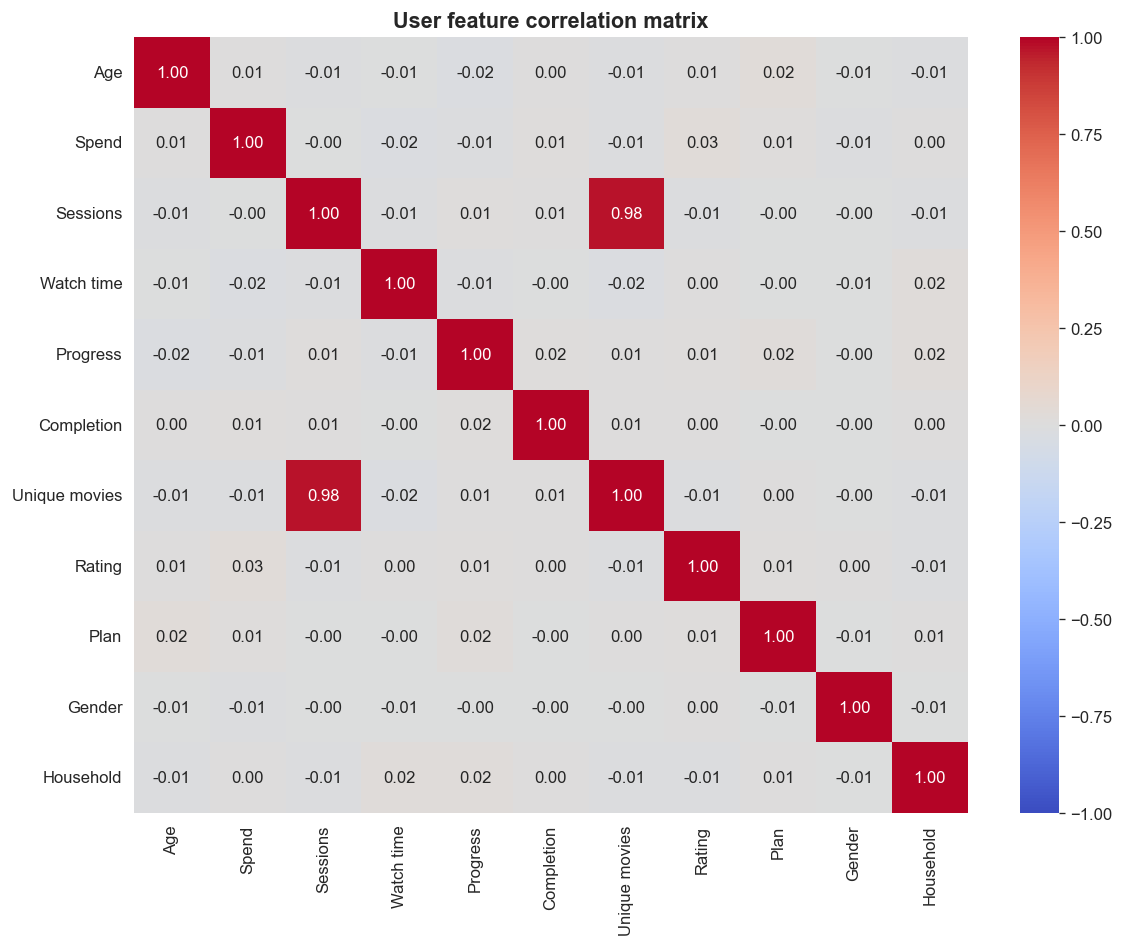

Variable pairs with |correlation| > 0.8 (potential redundancy):
  total_sessions <-> unique_movies_watched: r = 0.98  -> REMOVE one of them


In [5]:
fig, ax = plt.subplots(figsize=(10, 8))

corr_cols = ['age','monthly_spend','total_sessions','avg_watch_duration',
             'avg_progress','completed_ratio','unique_movies_watched',
             'avg_rating','plan_enc','gender_enc','household_size']

corr_matrix = user_profiles[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            xticklabels=['Age','Spend','Sessions','Watch time',
                         'Progress','Completion','Unique movies',
                         'Rating','Plan','Gender','Household'],
            yticklabels=['Age','Spend','Sessions','Watch time',
                         'Progress','Completion','Unique movies',
                         'Rating','Plan','Gender','Household'])
ax.set_title('User feature correlation matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('wykres_korelacja.png', bbox_inches='tight')
plt.show()

print('Variable pairs with |correlation| > 0.8 (potential redundancy):')
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            print(f'  {corr_cols[i]} <-> {corr_cols[j]}: r = {r:.2f}  -> REMOVE one of them')

### 4.2 Outlier and distribution analysis — continuous variables only

We do not check categorical variables (plan_enc, gender_enc, household_size) for outliers — they have no outlying values in the traditional sense.

Variable                    Q1      Q3   Lower   Upper   Outliers      %   Skewness
----------------------------------------------------------------------------------
Age                      28.00   43.00    5.50   65.50         41   0.47%       0.27
Monthly spend (USD)       8.33   20.30   -9.63   38.26        427   4.88%      11.48
Number of sessions        8.00   13.00    0.50   20.50         38   0.43%       0.37
Avg. watch time (minutes)   50.54   71.30   19.38  102.46        500   5.71%       2.22
Avg. progress (%)        43.66   56.12   24.97   74.81         97   1.11%       0.00


Completion rate           0.14    0.33   -0.14    0.62        128   1.46%       0.53
Avg. rating               3.25    4.00    2.12    5.12        574   6.56%      -0.90


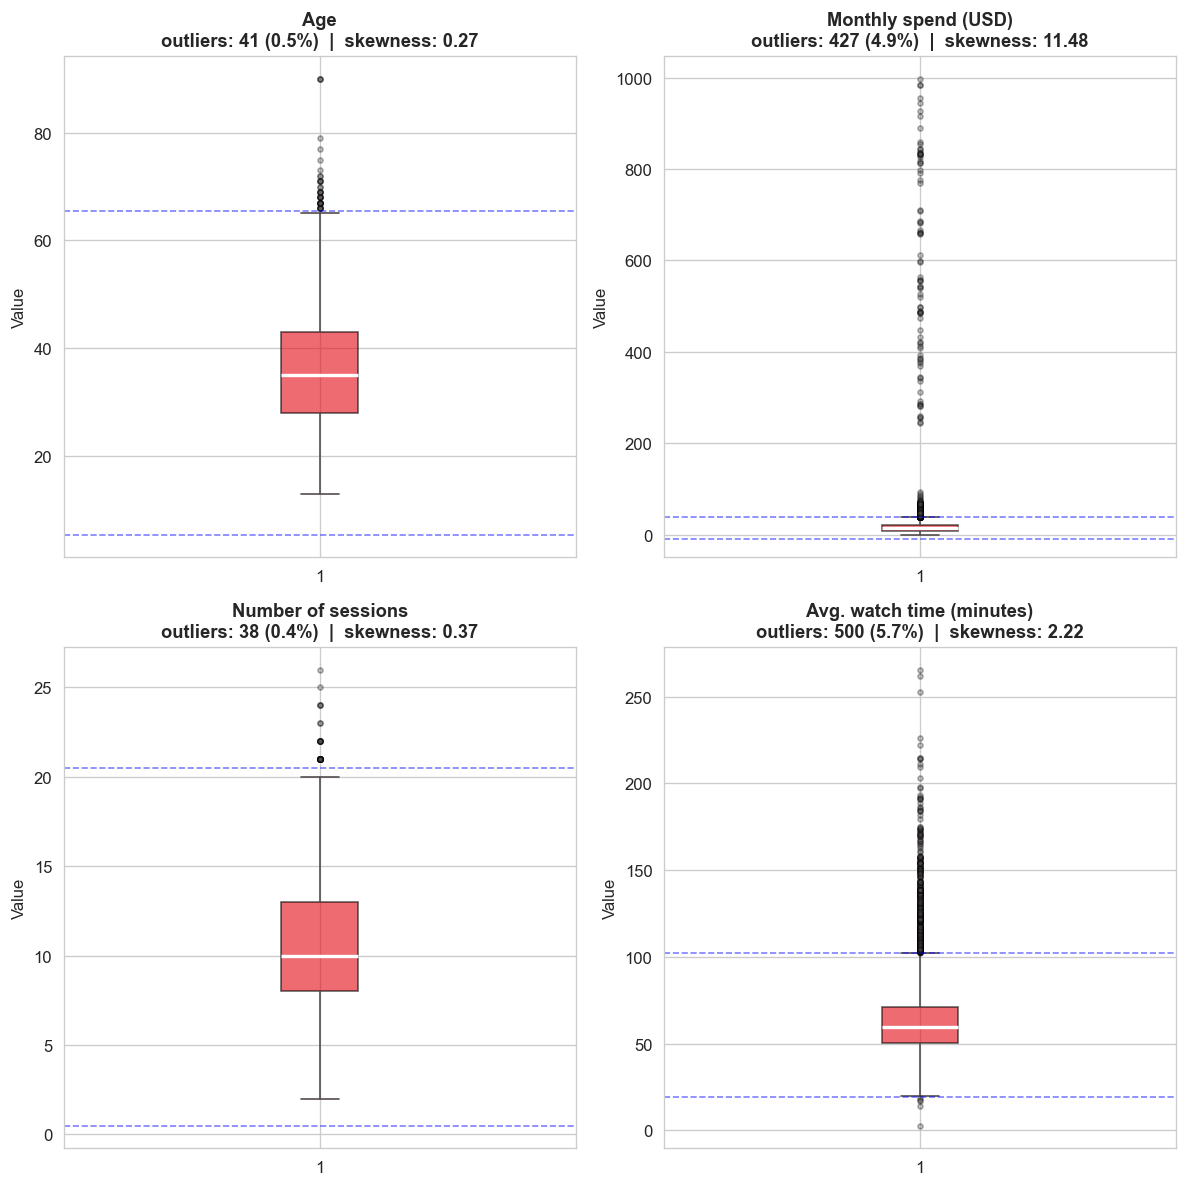

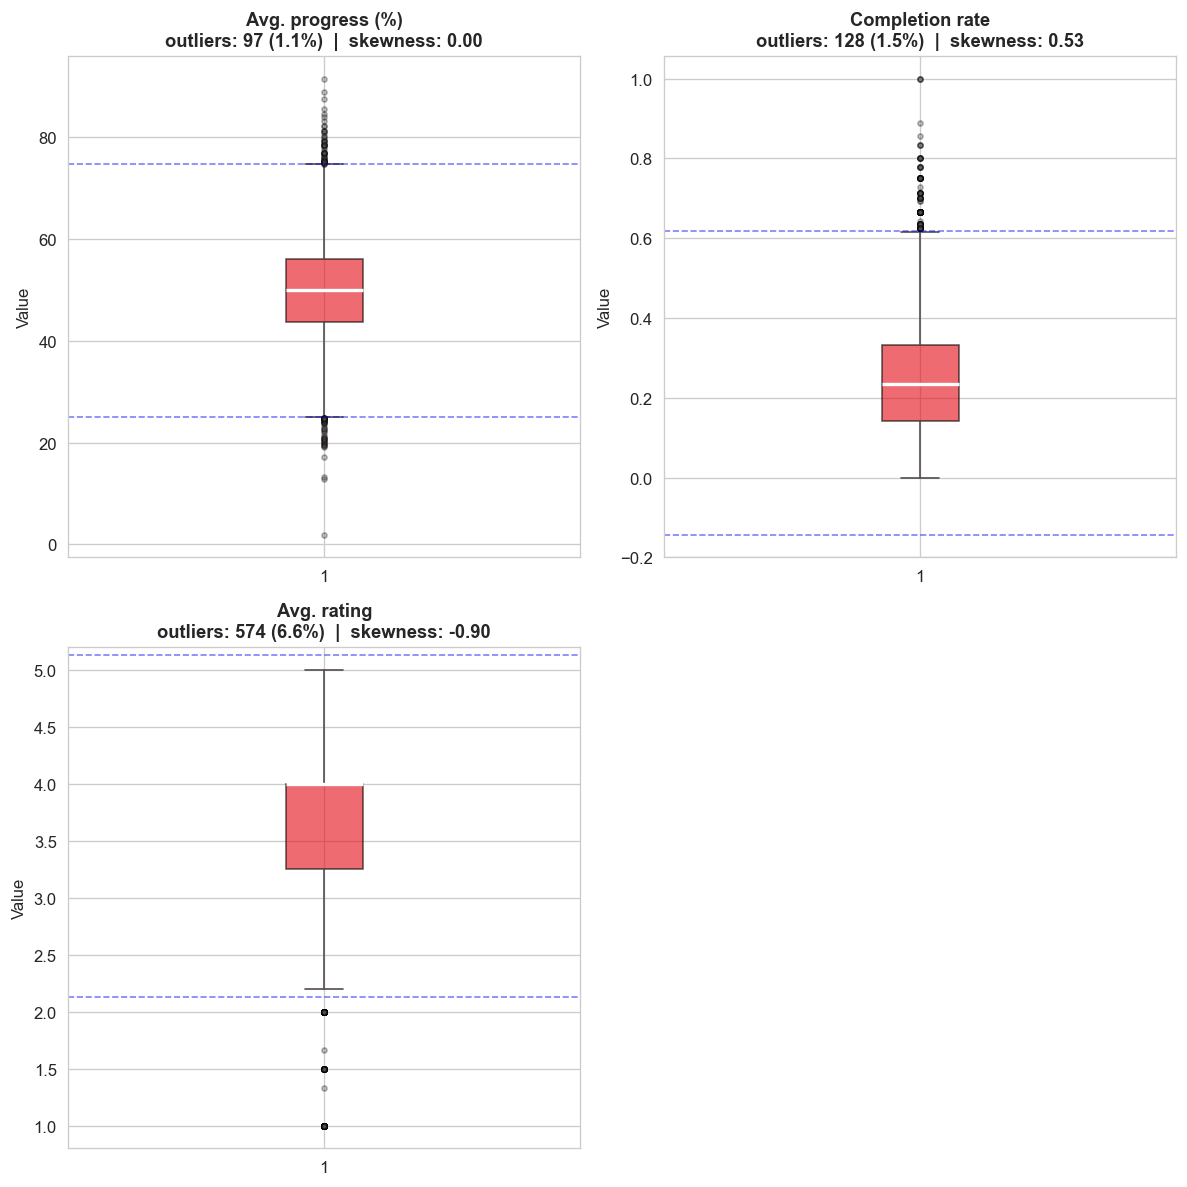

In [6]:
# Table (unchanged)
continuous_cols = ['age','monthly_spend','total_sessions','avg_watch_duration',
                   'avg_progress','completed_ratio','avg_rating']
cont_labels     = ['Age','Monthly spend (USD)','Number of sessions','Avg. watch time (minutes)',
                   'Avg. progress (%)','Completion rate','Avg. rating']


print(f"{'Variable':<22} {'Q1':>7} {'Q3':>7} {'Lower':>7} {'Upper':>7} {'Outliers':>10} {'%':>6} {'Skewness':>10}")
print('-' * 82)

outlier_data = []
for col, label in zip(continuous_cols, cont_labels):
    Q1    = user_profiles[col].quantile(0.25)
    Q3    = user_profiles[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((user_profiles[col] < lower) | (user_profiles[col] > upper)).sum()
    pct   = n_out / len(user_profiles) * 100
    skew  = stats.skew(user_profiles[col].dropna())
    outlier_data.append((col, label, Q1, Q3, lower, upper, n_out, pct, skew))
    print(f"{label:<22} {Q1:>7.2f} {Q3:>7.2f} {lower:>7.2f} {upper:>7.2f} {n_out:>10} {pct:>6.2f}% {skew:>10.2f}")

# Plot 1 — first 4 variables (2x2)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, (col, label, Q1, Q3, lower, upper, n_out, pct, skew) in enumerate(outlier_data[:4]):
    axes[i].boxplot(user_profiles[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#E50914', alpha=0.6),
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#564d4d'),
                    capprops=dict(color='#564d4d'),
                    flierprops=dict(marker='o', markerfacecolor='#564d4d',
                                   markersize=3, alpha=0.3))
    axes[i].set_title(f'{label}\noutliers: {n_out} ({pct:.1f}%)  |  skewness: {skew:.2f}',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].axhline(y=lower, color='blue', linestyle='--', alpha=0.5, linewidth=1)
    axes[i].axhline(y=upper, color='blue', linestyle='--', alpha=0.5, linewidth=1)


plt.tight_layout()
plt.savefig('wykres_boxploty_1.png', bbox_inches='tight')
plt.show()

# Plot 2 — remaining 3 variables (2x2 with one empty)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()

for i, (col, label, Q1, Q3, lower, upper, n_out, pct, skew) in enumerate(outlier_data[4:]):
    axes[i].boxplot(user_profiles[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#E50914', alpha=0.6),
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#564d4d'),
                    capprops=dict(color='#564d4d'),
                    flierprops=dict(marker='o', markerfacecolor='#564d4d',
                                   markersize=3, alpha=0.3))
    axes[i].set_title(f'{label}\noutliers: {n_out} ({pct:.1f}%)  |  skewness: {skew:.2f}',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].axhline(y=lower, color='blue', linestyle='--', alpha=0.5, linewidth=1)
    axes[i].axhline(y=upper, color='blue', linestyle='--', alpha=0.5, linewidth=1)

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('wykres_boxploty_2.png', bbox_inches='tight')
plt.show()

### 4.3 Log transformation of strongly skewed variables

We apply log1p to continuous variables with skewness |s| > 1.0:
- `monthly_spend` (skewness = 11.48)
- `avg_watch_duration` (skewness = 2.22)

We do not transform categorical and discrete variables.

Skewness before transformation:
  monthly_spend:      11.48
  avg_watch_duration: 2.22
Skewness after log1p transformation:
  monthly_spend_log:      0.71
  avg_watch_duration_log: 0.51


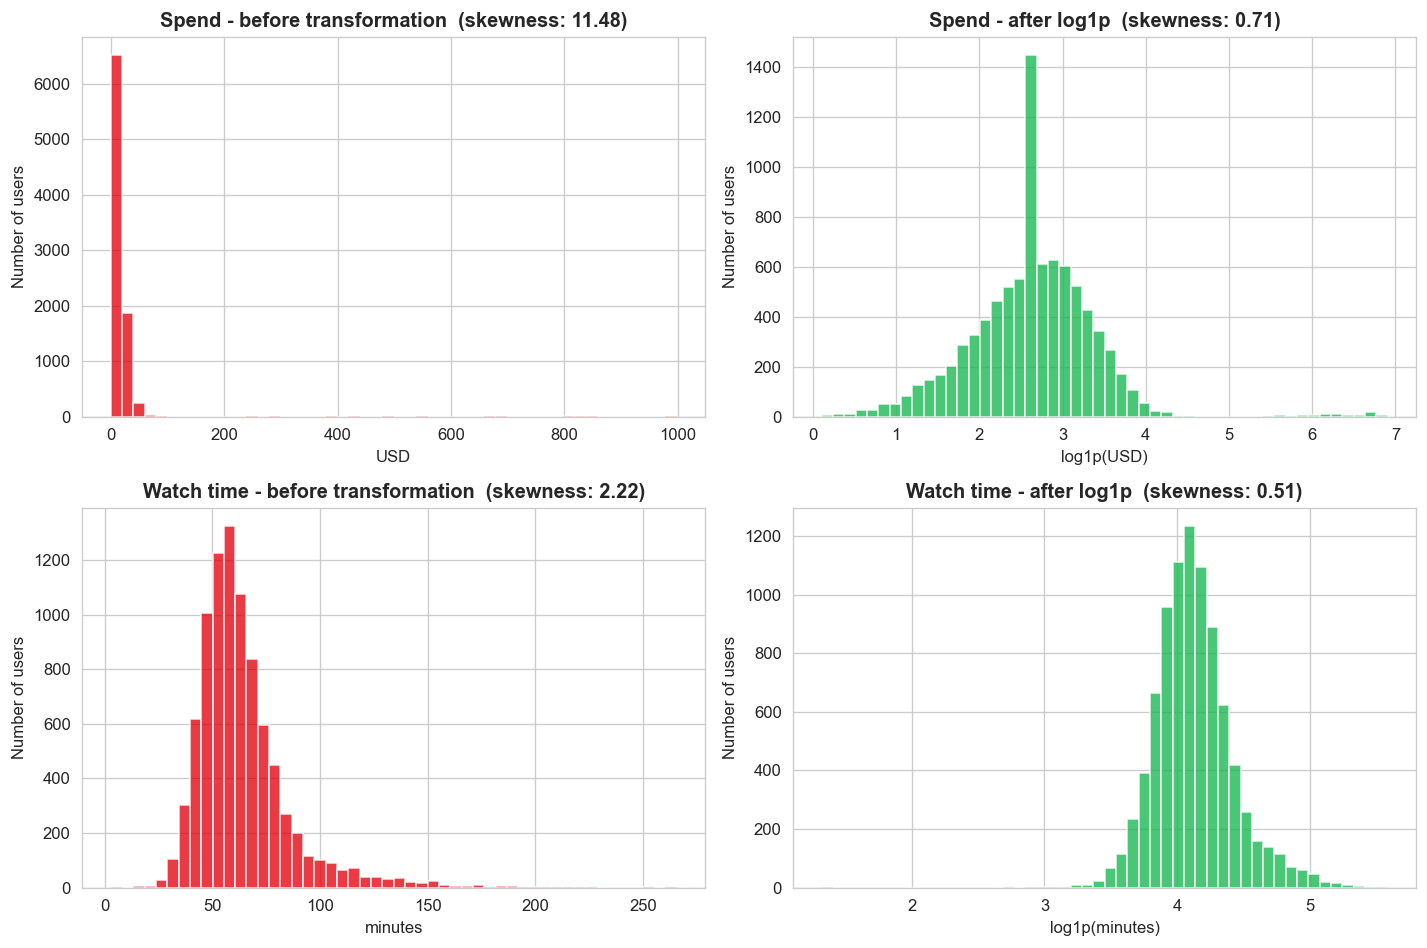

Skewness after log1p transformation:
  monthly_spend:      11.48  ->  monthly_spend_log:       0.71
  avg_watch_duration: 2.22  ->  avg_watch_duration_log:  0.51


In [7]:
# Log transformation of strongly skewed variables
user_profiles['monthly_spend_log']      = np.log1p(user_profiles['monthly_spend'])
user_profiles['avg_watch_duration_log'] = np.log1p(user_profiles['avg_watch_duration'])

print('Skewness before transformation:')
print(f'  monthly_spend:      {stats.skew(user_profiles["monthly_spend"]):.2f}')
print(f'  avg_watch_duration: {stats.skew(user_profiles["avg_watch_duration"]):.2f}')
print('Skewness after log1p transformation:')
print(f'  monthly_spend_log:      {stats.skew(user_profiles["monthly_spend_log"]):.2f}')
print(f'  avg_watch_duration_log: {stats.skew(user_profiles["avg_watch_duration_log"]):.2f}')
# Verifying the log1p transformation - comparing distributions before and after
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(user_profiles['monthly_spend'], bins=50, color='#E50914', edgecolor='white', alpha=0.8)
axes[0,0].set_title(f'Spend - before transformation  (skewness: {stats.skew(user_profiles["monthly_spend"]):.2f})', fontweight='bold')
axes[0,0].set_xlabel('USD')
axes[0,0].set_ylabel('Number of users')

axes[0,1].hist(user_profiles['monthly_spend_log'], bins=50, color='#1DB954', edgecolor='white', alpha=0.8)
axes[0,1].set_title(f'Spend - after log1p  (skewness: {stats.skew(user_profiles["monthly_spend_log"]):.2f})', fontweight='bold')
axes[0,1].set_xlabel('log1p(USD)')
axes[0,1].set_ylabel('Number of users')

axes[1,0].hist(user_profiles['avg_watch_duration'], bins=50, color='#E50914', edgecolor='white', alpha=0.8)
axes[1,0].set_title(f'Watch time - before transformation  (skewness: {stats.skew(user_profiles["avg_watch_duration"]):.2f})', fontweight='bold')
axes[1,0].set_xlabel('minutes')
axes[1,0].set_ylabel('Number of users')

axes[1,1].hist(user_profiles['avg_watch_duration_log'], bins=50, color='#1DB954', edgecolor='white', alpha=0.8)
axes[1,1].set_title(f'Watch time - after log1p  (skewness: {stats.skew(user_profiles["avg_watch_duration_log"]):.2f})', fontweight='bold')
axes[1,1].set_xlabel('log1p(minutes)')
axes[1,1].set_ylabel('Number of users')


plt.tight_layout()
plt.savefig('wykres_transformacja_log.png', bbox_inches='tight')
plt.show()

print('Skewness after log1p transformation:')
print(f'  monthly_spend:      {stats.skew(user_profiles["monthly_spend"]):.2f}  ->  monthly_spend_log:       {stats.skew(user_profiles["monthly_spend_log"]):.2f}')
print(f'  avg_watch_duration: {stats.skew(user_profiles["avg_watch_duration"]):.2f}  ->  avg_watch_duration_log:  {stats.skew(user_profiles["avg_watch_duration_log"]):.2f}')

### 4.4 Final feature list and scaling

- **Continuous variables** -> StandardScaler (mean=0, std=1)
- **Categorical variables** -> MinMaxScaler (range 0-1)
- `unique_movies_watched` excluded due to correlation r=0.98 with `total_sessions`

In [8]:
continuous_features  = ['age', 'monthly_spend_log', 'total_sessions',
                         'avg_watch_duration_log', 'avg_progress',
                         'completed_ratio', 'avg_rating']
categorical_features = ['plan_enc', 'gender_enc', 'household_size']
cluster_features     = continuous_features + categorical_features

X_cont = user_profiles[continuous_features].values
X_cat  = user_profiles[categorical_features].values

scaler_cont   = StandardScaler()
scaler_cat    = MinMaxScaler()
X_cont_scaled = scaler_cont.fit_transform(X_cont)
X_cat_scaled  = scaler_cat.fit_transform(X_cat)
X_scaled      = np.hstack([X_cont_scaled, X_cat_scaled])

print(f'Feature matrix for clustering: {X_scaled.shape}')
print(f'  Continuous (StandardScaler):  {len(continuous_features)}')
for f in continuous_features:
    print(f'    - {f}')
print(f'  Categorical (MinMaxScaler):   {len(categorical_features)}')
for f in categorical_features:
    print(f'    - {f}')

Feature matrix for clustering: (8751, 10)
  Continuous (StandardScaler):  7
    - age
    - monthly_spend_log
    - total_sessions
    - avg_watch_duration_log
    - avg_progress
    - completed_ratio
    - avg_rating
  Categorical (MinMaxScaler):   3
    - plan_enc
    - gender_enc
    - household_size


## 5. User clustering — K-means

### 5.1 Elbow method — choosing the optimal number of clusters

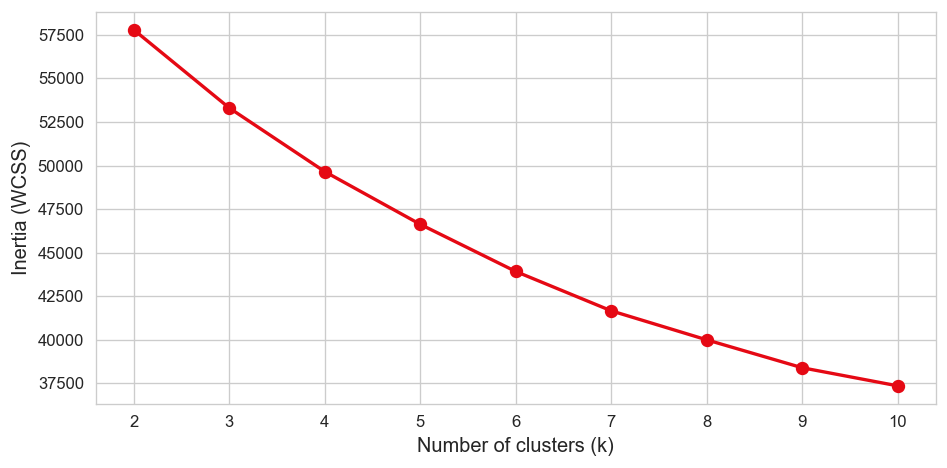

In [9]:
inertias = []
K_range  = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, 'o-', color='#E50914', linewidth=2, markersize=7)
ax.set_xlabel('Number of clusters (k)', fontsize=12)
ax.set_ylabel('Inertia (WCSS)', fontsize=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('wykres_elbow.png', bbox_inches='tight')
plt.show()

### 5.2 Clustering with the optimal number of clusters k

In [10]:
K_OPTIMAL = 4
colors    = ['#E50914','#1DB954','#0063e5','#f5a623']

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
user_profiles['cluster'] = kmeans.fit_predict(X_scaled)

print('Number of users in each cluster:')
for c, n in user_profiles['cluster'].value_counts().sort_index().items():
    print(f'  Cluster {c}: {n:,} users')

Number of users in each cluster:
  Cluster 0: 2,110 users
  Cluster 1: 1,609 users
  Cluster 2: 2,359 users
  Cluster 3: 2,673 users


### 5.3 Cluster visualization — PCA 2D

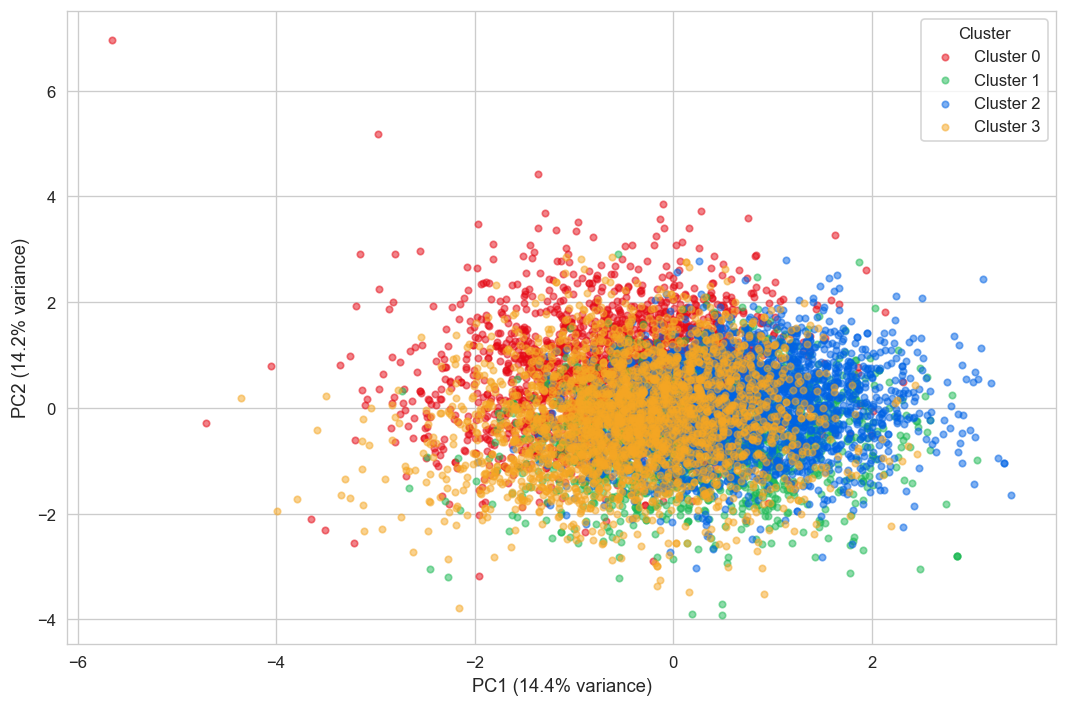

In [11]:



pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df            = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['cluster'] = user_profiles['cluster'].values

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(K_OPTIMAL):
    mask = pca_df['cluster'] == c
    ax.scatter(pca_df.loc[mask,'PC1'], pca_df.loc[mask,'PC2'],
               s=15, alpha=0.5, color=colors[c], label=f'Cluster {c}')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
ax.legend(title='Cluster', fontsize=10)
plt.tight_layout()
plt.savefig('wykres_pca_klastry.png', bbox_inches='tight')
plt.show()

In [12]:
# How much variance is explained by successive PCA components
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

print('Variance explained by successive PCA components:')
for i, v in enumerate(cumvar):
    print(f'PC1-PC{i+1}: {v:.1f}%')

print()

# Check whether 80% has been reached
if np.any(cumvar >= 80):
    n_80 = np.argmax(cumvar >= 80) + 1
    print(f'Number of components needed to explain 80% of variance: {n_80}')
else:
    print(f'80% of variance was not reached. Maximum explained: {cumvar[-1]:.1f}%')

Variance explained by successive PCA components:
PC1-PC1: 14.4%
PC1-PC2: 28.6%

80% of variance was not reached. Maximum explained: 28.6%


### 5.4 Cluster characteristics

In [13]:
cluster_profile = user_profiles.groupby('cluster').agg(
    num_users        = ('user_id', 'count'),
    avg_age           = ('age', 'mean'),
    avg_spend         = ('monthly_spend', 'mean'),
    avg_num_sessions  = ('total_sessions', 'mean'),
    avg_watch_time    = ('avg_watch_duration', 'mean'),
    completion_rate   = ('completed_ratio', 'mean'),
    avg_rating        = ('avg_rating', 'mean')
).round(2)

cluster_profile.columns = ['Num. users', 'Avg. age', 'Avg. spend (USD)',
                            'Avg. num. sessions', 'Avg. watch time (min)',
                            'Completion rate', 'Avg. rating']
print('User cluster characteristics:')
cluster_profile

User cluster characteristics:


,Num. users,Avg. age,Avg. spend (USD),Avg. num. sessions,Avg. watch time (min),Completion rate,Avg. rating
cluster,,,,,,,
0,2110,37.29,29.21,8.86,60.83,0.42,3.96
1,1609,35.13,17.72,10.86,63.86,0.23,2.46
2,2359,35.64,15.75,14.15,65.12,0.24,4.04
3,2673,35.11,20.91,8.33,65.51,0.13,4.04


### 5.5 Radar chart — cluster profiles

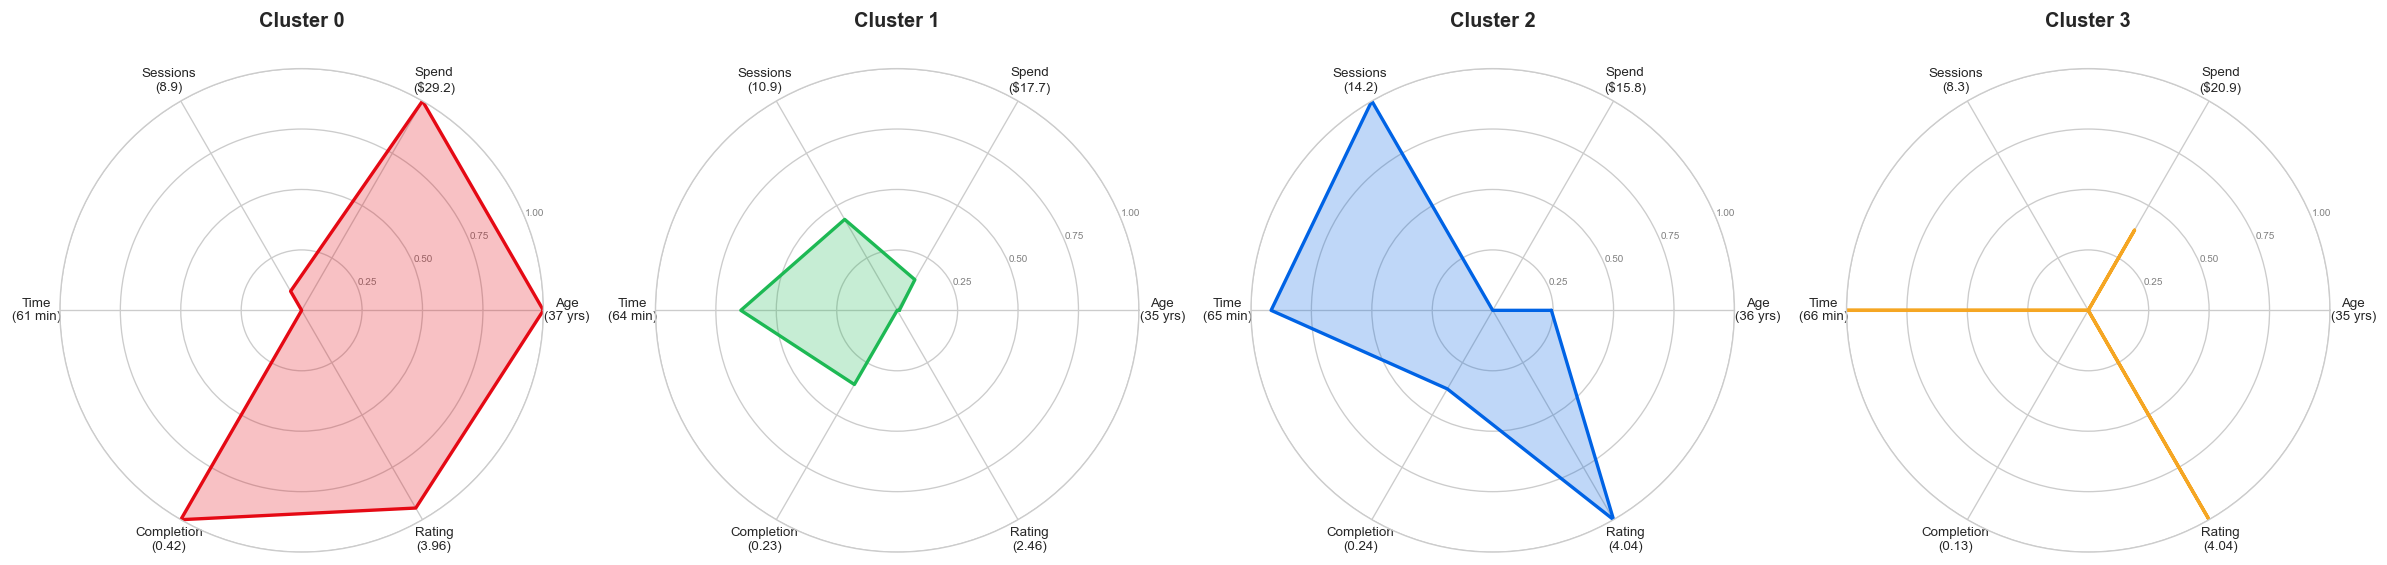

In [14]:
radar_features = ['age','monthly_spend','total_sessions',
                  'avg_watch_duration','completed_ratio','avg_rating']

cluster_means = user_profiles.groupby('cluster')[radar_features].mean()
cluster_norm  = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

N      = len(radar_features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, K_OPTIMAL, figsize=(5*K_OPTIMAL, 5),
                          subplot_kw=dict(polar=True))
if K_OPTIMAL == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    vals = cluster_norm.iloc[i].tolist() + cluster_norm.iloc[i].tolist()[:1]
    real = cluster_means.iloc[i]

    ax.plot(angles, vals, color=colors[i], linewidth=2)
    ax.fill(angles, vals, color=colors[i], alpha=0.25)
    ax.set_xticks(angles[:-1])

    # Labels with actual values below
    labels_with_vals = [
        f'Age\n({real["age"]:.0f} yrs)',
        f'Spend\n(${real["monthly_spend"]:.1f})',
        f'Sessions\n({real["total_sessions"]:.1f})',
        f'Time\n({real["avg_watch_duration"]:.0f} min)',
        f'Completion\n({real["completed_ratio"]:.2f})',
        f'Rating\n({real["avg_rating"]:.2f})'
    ]
    ax.set_xticklabels(labels_with_vals, size=8)
    ax.set_title(f'Cluster {i}', size=12, fontweight='bold', pad=25)
    ax.set_ylim(0, 1)

    # Grid every 0.25
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.50','0.75','1.00'], size=6, color='grey')

plt.tight_layout()
plt.savefig('wykres_radar_klastry.png', bbox_inches='tight')
plt.show()

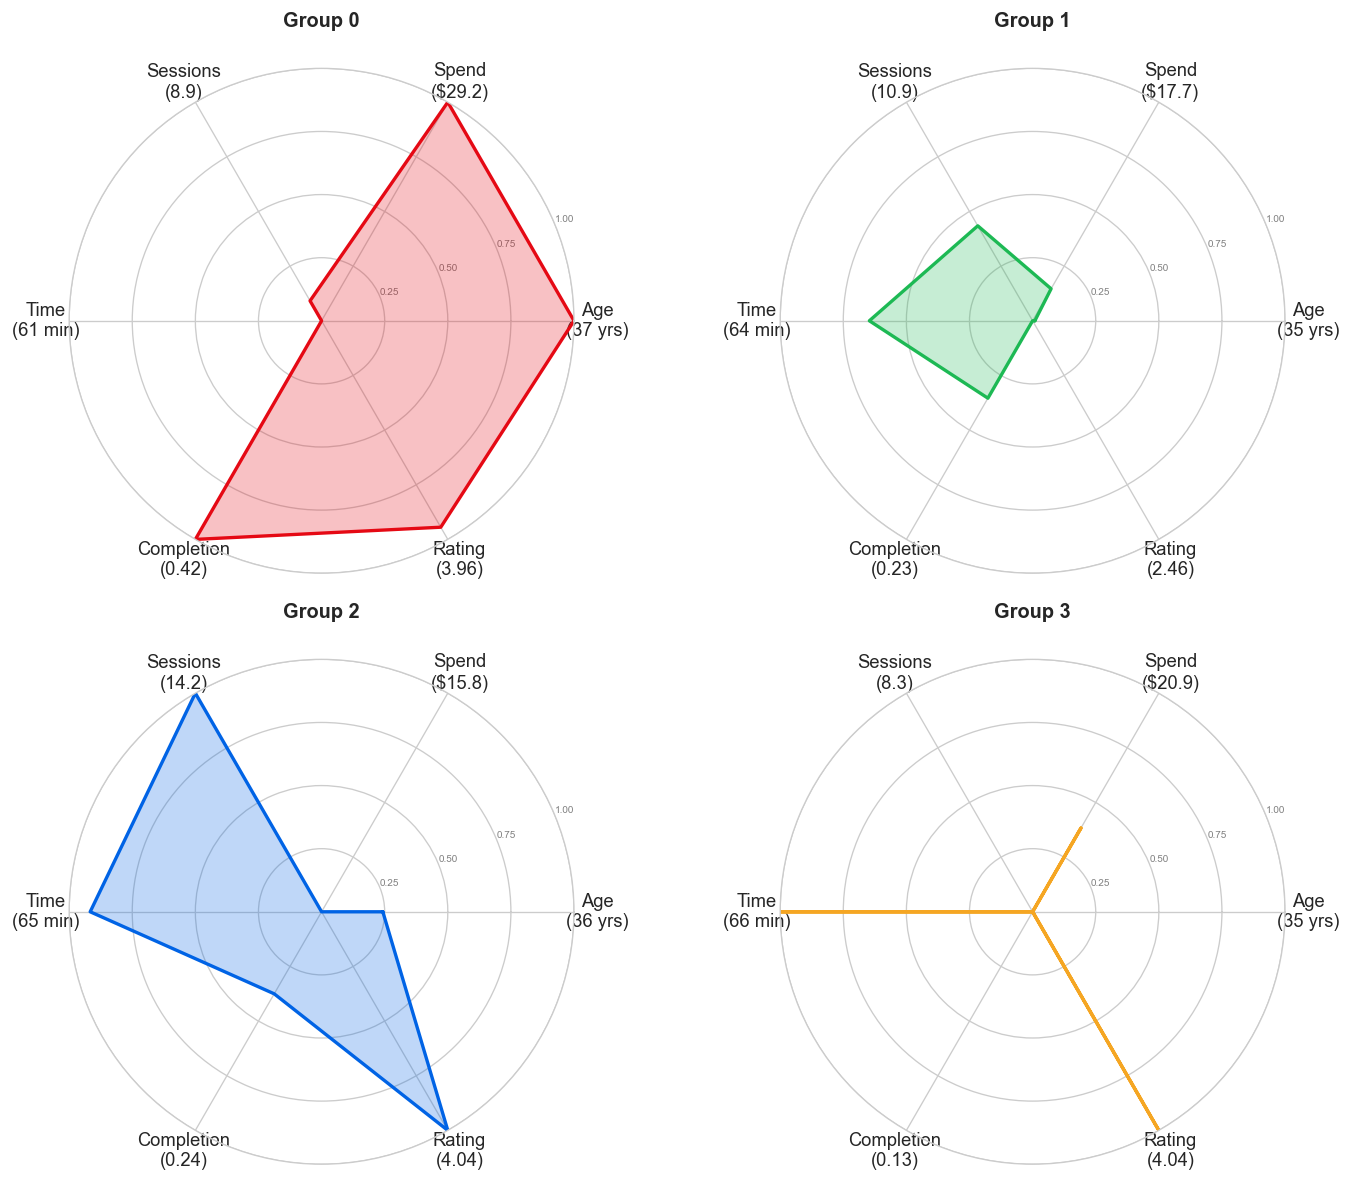

In [15]:
radar_features = ['age','monthly_spend','total_sessions',
                  'avg_watch_duration','completed_ratio','avg_rating']
cluster_means = user_profiles.groupby('cluster')[radar_features].mean()
cluster_norm  = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

N      = len(radar_features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(12, 10),
                         subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, ax in enumerate(axes):
    vals = cluster_norm.iloc[i].tolist() + cluster_norm.iloc[i].tolist()[:1]
    real = cluster_means.iloc[i]
    ax.plot(angles, vals, color=colors[i], linewidth=2)
    ax.fill(angles, vals, color=colors[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    labels_with_vals = [
        f'Age\n({real["age"]:.0f} yrs)',
        f'Spend\n(${real["monthly_spend"]:.1f})',
        f'Sessions\n({real["total_sessions"]:.1f})',
        f'Time\n({real["avg_watch_duration"]:.0f} min)',
        f'Completion\n({real["completed_ratio"]:.2f})',
        f'Rating\n({real["avg_rating"]:.2f})'
    ]
    ax.set_xticklabels(labels_with_vals, size=11)
    ax.set_title(f'Group {i}', size=12, fontweight='bold', pad=25)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.50','0.75','1.00'], size=6, color='grey')

plt.tight_layout()
plt.savefig('wykres_radar_grupy.png', bbox_inches='tight')
plt.show()

## 6. Recommendation system — collaborative filtering

Two variants:
- **Baseline CF** — KNN over all users
- **CF with clusters** — KNN within a cluster only (Liu Xiaojun, 2017)

In [16]:
ratings = reviews[['user_id','movie_id','rating']].copy()

users_in_ratings  = ratings['user_id'].unique()
movies_in_ratings = ratings['movie_id'].unique()

user2idx  = {u: i for i, u in enumerate(users_in_ratings)}
movie2idx = {m: i for i, m in enumerate(movies_in_ratings)}
idx2movie = {i: m for m, i in movie2idx.items()}

ratings['u_idx'] = ratings['user_id'].map(user2idx)
ratings['m_idx'] = ratings['movie_id'].map(movie2idx)

train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

n_users  = len(users_in_ratings)
n_movies = len(movies_in_ratings)
train_matrix = csr_matrix(
    (train_df['rating'].values, (train_df['u_idx'].values, train_df['m_idx'].values)),
    shape=(n_users, n_movies)
)

density = ratings.shape[0] / (n_users * n_movies) * 100
print(f'Ratings matrix: {n_users} users x {n_movies} movies')
print(f'Matrix density: {density:.2f}%')
print(f'Training set: {len(train_df):,} ratings')
print(f'Test set:     {len(test_df):,} ratings')

Ratings matrix: 7761 users x 1000 movies
Matrix density: 0.20%
Training set: 12,360 ratings
Test set:     3,090 ratings


### 6.1 Prediction functions

In [17]:
def predict_ratings_knn(test_df, train_matrix, n_neighbors=20, metric='cosine'):
    """Baseline CF: user-based KNN over all users."""
    model = NearestNeighbors(n_neighbors=n_neighbors+1, metric=metric, algorithm='brute')
    model.fit(train_matrix)
    preds, actuals = [], []
    for _, row in test_df.iterrows():
        u, m, actual = int(row['u_idx']), int(row['m_idx']), row['rating']
        distances, indices = model.kneighbors(train_matrix[u], n_neighbors=n_neighbors+1)
        neighbors = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if idx != u]
        ratings_n, sims = [], []
        for n_idx, dist in neighbors:
            r = train_matrix[n_idx, m]
            if r > 0:
                ratings_n.append(r); sims.append(1 - dist)
        if ratings_n and sum(sims) > 0:
            pred = np.average(ratings_n, weights=sims)
        else:
            nz = train_matrix[:, m].data
            pred = nz.mean() if len(nz) > 0 else 3.0
        preds.append(np.clip(pred, 1, 5)); actuals.append(actual)
    return np.array(actuals), np.array(preds)


def predict_ratings_cluster_cf(test_df, train_df_full, user_profiles,
                                user2idx, train_matrix, movie2idx,
                                n_neighbors=20, metric='cosine'):
    """CF with clusters and fallback to global CF (Liu Xiaojun, 2017)."""
    user_cluster = user_profiles.set_index('user_id')['cluster'].to_dict()
    global_model = NearestNeighbors(n_neighbors=n_neighbors+1, metric=metric, algorithm='brute')
    global_model.fit(train_matrix)

    preds, actuals = [], []
    for _, row in test_df.iterrows():
        u_id, m_id, actual = row['user_id'], row['movie_id'], row['rating']
        u_g = user2idx.get(u_id, -1)
        m_g = movie2idx.get(m_id, -1)
        pred = None

        # Try predicting within the cluster
        cluster_id    = user_cluster.get(u_id, -1)
        cluster_users = user_profiles[user_profiles['cluster'] == cluster_id]['user_id'].values
        cluster_train = train_df_full[train_df_full['user_id'].isin(cluster_users)]

        if len(cluster_train) > 0 and u_g >= 0:
            c_users  = cluster_train['user_id'].unique()
            c_movies = cluster_train['movie_id'].unique()
            cu2i = {u: i for i, u in enumerate(c_users)}
            cm2i = {m: i for i, m in enumerate(c_movies)}
            if u_id in cu2i and m_id in cm2i:
                cluster_matrix = csr_matrix(
                    (cluster_train['rating'].values,
                     (cluster_train['user_id'].map(cu2i).values,
                      cluster_train['movie_id'].map(cm2i).values)),
                    shape=(len(c_users), len(c_movies))
                )
                u_local, m_local = cu2i[u_id], cm2i[m_id]
                k     = min(n_neighbors + 1, len(c_users))
                model = NearestNeighbors(n_neighbors=k, metric=metric, algorithm='brute')
                model.fit(cluster_matrix)
                distances, indices = model.kneighbors(cluster_matrix[u_local], n_neighbors=k)
                neighbors = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if idx != u_local]
                ratings_n, sims = [], []
                for n_idx, dist in neighbors:
                    r = cluster_matrix[n_idx, m_local]
                    if r > 0:
                        ratings_n.append(r); sims.append(1 - dist)
                if ratings_n and sum(sims) > 0:
                    pred = np.average(ratings_n, weights=sims)

        # Fallback: global CF
        if pred is None and u_g >= 0:
            distances, indices = global_model.kneighbors(train_matrix[u_g], n_neighbors=n_neighbors+1)
            neighbors = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if idx != u_g]
            ratings_n, sims = [], []
            for n_idx, dist in neighbors:
                r = train_matrix[n_idx, m_g] if m_g >= 0 else 0
                if r > 0:
                    ratings_n.append(r); sims.append(1 - dist)
            if ratings_n and sum(sims) > 0:
                pred = np.average(ratings_n, weights=sims)

        # Final fallback: global mean
        if pred is None:
            nz = train_matrix[:, m_g].data if m_g >= 0 else []
            pred = nz.mean() if len(nz) > 0 else (train_matrix.data.mean() if len(train_matrix.data) > 0 else 3.5)

        preds.append(np.clip(pred, 1, 5)); actuals.append(actual)
    return np.array(actuals), np.array(preds)

print('Prediction functions ready.')

Prediction functions ready.


### 6.2 Evaluation for k in {10, 15, 20, 25, 30, 35} — following Lee et al. (2012)

In [18]:
cluster_map = (
    user_profiles[["user_id", "cluster"]]
    .drop_duplicates(subset="user_id")
    .set_index("user_id")["cluster"]
)

test_with_cluster = test_df.copy()
test_with_cluster["cluster"] = test_with_cluster["user_id"].map(cluster_map)
test_with_cluster = test_with_cluster.dropna(subset=["cluster"])

N_EVAL = len(test_with_cluster)
test_sample = test_with_cluster.sample(N_EVAL, random_state=42)
K_VALUES    = [10, 15, 20, 25, 30, 35]
results     = []

print(f"Evaluating on {N_EVAL} test examples...")
print(f"\n{'KN':>4} | {'MAE Baseline CF':>14} | {'RMSE Baseline CF':>14} | {'MAE CF+Clusters':>14} | {'RMSE CF+Clusters':>15}")
print("-" * 72)

for k in K_VALUES:
    y_true_b, y_pred_b = predict_ratings_knn(test_sample, train_matrix, n_neighbors=k)
    mae_b  = mean_absolute_error(y_true_b, y_pred_b)
    rmse_b = np.sqrt(mean_squared_error(y_true_b, y_pred_b))

    y_true_c, y_pred_c = predict_ratings_cluster_cf(
        test_sample, train_df, user_profiles, user2idx,
        train_matrix, movie2idx, n_neighbors=k)
    mae_c  = mean_absolute_error(y_true_c, y_pred_c)
    rmse_c = np.sqrt(mean_squared_error(y_true_c, y_pred_c))

    results.append({"KN": k, "MAE_base": mae_b, "RMSE_base": rmse_b,
                    "MAE_cluster": mae_c, "RMSE_cluster": rmse_c})
    print(f"{k:>4} | {mae_b:>14.3f} | {rmse_b:>14.3f} | {mae_c:>14.3f} | {rmse_c:>15.3f}")

results_df = pd.DataFrame(results)

Evaluating on 2652 test examples...

  KN | MAE Baseline CF | RMSE Baseline CF | MAE CF+Clusters | RMSE CF+Clusters
------------------------------------------------------------------------


  10 |          0.958 |          1.183 |          0.954 |           1.179


  15 |          0.958 |          1.184 |          0.955 |           1.182


  20 |          0.959 |          1.185 |          0.956 |           1.183


  25 |          0.959 |          1.185 |          0.956 |           1.183


  30 |          0.960 |          1.186 |          0.957 |           1.184


  35 |          0.960 |          1.187 |          0.957 |           1.184


In [19]:
def predict_ratings_knn(test_df, train_matrix, n_neighbors=20, metric='cosine'):
    """Baseline CF: user-based KNN over all users."""
    model = NearestNeighbors(n_neighbors=n_neighbors+1, metric=metric, algorithm='brute')
    model.fit(train_matrix)
    preds, actuals = [], []
    for _, row in test_df.iterrows():
        u, m, actual = int(row['u_idx']), int(row['m_idx']), row['rating']
        distances, indices = model.kneighbors(train_matrix[u], n_neighbors=n_neighbors+1)
        neighbors = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if idx != u]
        ratings_n, sims = [], []
        for n_idx, dist in neighbors:
            r = train_matrix[n_idx, m]
            if r > 0:
                ratings_n.append(r); sims.append(1 - dist)
        if ratings_n and sum(sims) > 0:
            pred = np.average(ratings_n, weights=sims)
        else:
            nz = train_matrix[:, m].data
            pred = nz.mean() if len(nz) > 0 else 3.0
        preds.append(np.clip(pred, 1, 5)); actuals.append(actual)
    return np.array(actuals), np.array(preds)


def predict_ratings_cluster_cf(test_df, train_df_full, user_profiles,
                                user2idx, train_matrix, movie2idx,
                                n_neighbors=20, metric='cosine'):
    """CF with clusters and fallback to global CF (Liu Xiaojun, 2017)."""
    user_cluster = user_profiles.set_index('user_id')['cluster'].to_dict()
    global_model = NearestNeighbors(n_neighbors=n_neighbors+1, metric=metric, algorithm='brute')
    global_model.fit(train_matrix)

    preds, actuals = [], []
    for _, row in test_df.iterrows():
        u_id, m_id, actual = row['user_id'], row['movie_id'], row['rating']
        u_g = user2idx.get(u_id, -1)
        m_g = movie2idx.get(m_id, -1)
        pred = None

        # Try predicting within the cluster
        cluster_id    = user_cluster.get(u_id, -1)
        cluster_users = user_profiles[user_profiles['cluster'] == cluster_id]['user_id'].values
        cluster_train = train_df_full[train_df_full['user_id'].isin(cluster_users)]

        if len(cluster_train) > 0 and u_g >= 0:
            c_users  = cluster_train['user_id'].unique()
            c_movies = cluster_train['movie_id'].unique()
            cu2i = {u: i for i, u in enumerate(c_users)}
            cm2i = {m: i for i, m in enumerate(c_movies)}
            if u_id in cu2i and m_id in cm2i:
                cluster_matrix = csr_matrix(
                    (cluster_train['rating'].values,
                     (cluster_train['user_id'].map(cu2i).values,
                      cluster_train['movie_id'].map(cm2i).values)),
                    shape=(len(c_users), len(c_movies))
                )
                u_local, m_local = cu2i[u_id], cm2i[m_id]
                k     = min(n_neighbors + 1, len(c_users))
                model = NearestNeighbors(n_neighbors=k, metric=metric, algorithm='brute')
                model.fit(cluster_matrix)
                distances, indices = model.kneighbors(cluster_matrix[u_local], n_neighbors=k)
                neighbors = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if idx != u_local]
                ratings_n, sims = [], []
                for n_idx, dist in neighbors:
                    r = cluster_matrix[n_idx, m_local]
                    if r > 0:
                        ratings_n.append(r); sims.append(1 - dist)
                if ratings_n and sum(sims) > 0:
                    pred = np.average(ratings_n, weights=sims)

        # Fallback: global CF
        if pred is None and u_g >= 0:
            distances, indices = global_model.kneighbors(train_matrix[u_g], n_neighbors=n_neighbors+1)
            neighbors = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if idx != u_g]
            ratings_n, sims = [], []
            for n_idx, dist in neighbors:
                r = train_matrix[n_idx, m_g] if m_g >= 0 else 0
                if r > 0:
                    ratings_n.append(r); sims.append(1 - dist)
            if ratings_n and sum(sims) > 0:
                pred = np.average(ratings_n, weights=sims)

        # Final fallback: global mean
        if pred is None:
            nz = train_matrix[:, m_g].data if m_g >= 0 else []
            pred = nz.mean() if len(nz) > 0 else (train_matrix.data.mean() if len(train_matrix.data) > 0 else 3.5)

        preds.append(np.clip(pred, 1, 5)); actuals.append(actual)
    return np.array(actuals), np.array(preds)

print('Prediction functions ready.')

Prediction functions ready.


### 6.3 Results comparison table

In [20]:
results_df['Better_MAE'] = results_df.apply(
    lambda r: 'CF+Clusters' if r['MAE_cluster'] < r['MAE_base'] else 'Baseline CF', axis=1)

display_df = results_df.copy()
display_df.columns = ['Num. neighbors KN','MAE Baseline CF','RMSE Baseline CF',
                       'MAE CF+Clusters','RMSE CF+Clusters','Better (MAE)']
display_df = display_df.round(3)

avg_row = display_df[['MAE Baseline CF','RMSE Baseline CF',
                       'MAE CF+Clusters','RMSE CF+Clusters']].mean().round(3)
avg_row['Num. neighbors KN'] = 'Average'
avg_row['Better (MAE)'] = 'CF+Clusters' if avg_row['MAE CF+Clusters'] < avg_row['MAE Baseline CF'] else 'Baseline CF'
display_df = pd.concat([display_df, pd.DataFrame([avg_row])], ignore_index=True)

print('Table 1. Comparison of MAE and RMSE across recommendation algorithms')
display_df

Table 1. Comparison of MAE and RMSE across recommendation algorithms


,Num. neighbors KN,MAE Baseline CF,RMSE Baseline CF,MAE CF+Clusters,RMSE CF+Clusters,Better (MAE)
0,10,0.958,1.183,0.954,1.179,CF+Clusters
1,15,0.958,1.184,0.955,1.182,CF+Clusters
2,20,0.959,1.185,0.956,1.183,CF+Clusters
3,25,0.959,1.185,0.956,1.183,CF+Clusters
4,30,0.960,1.186,0.957,1.184,CF+Clusters
5,35,0.960,1.187,0.957,1.184,CF+Clusters
6,Average,0.959,1.185,0.956,1.182,CF+Clusters


### 6.4 MAE and RMSE comparison plot

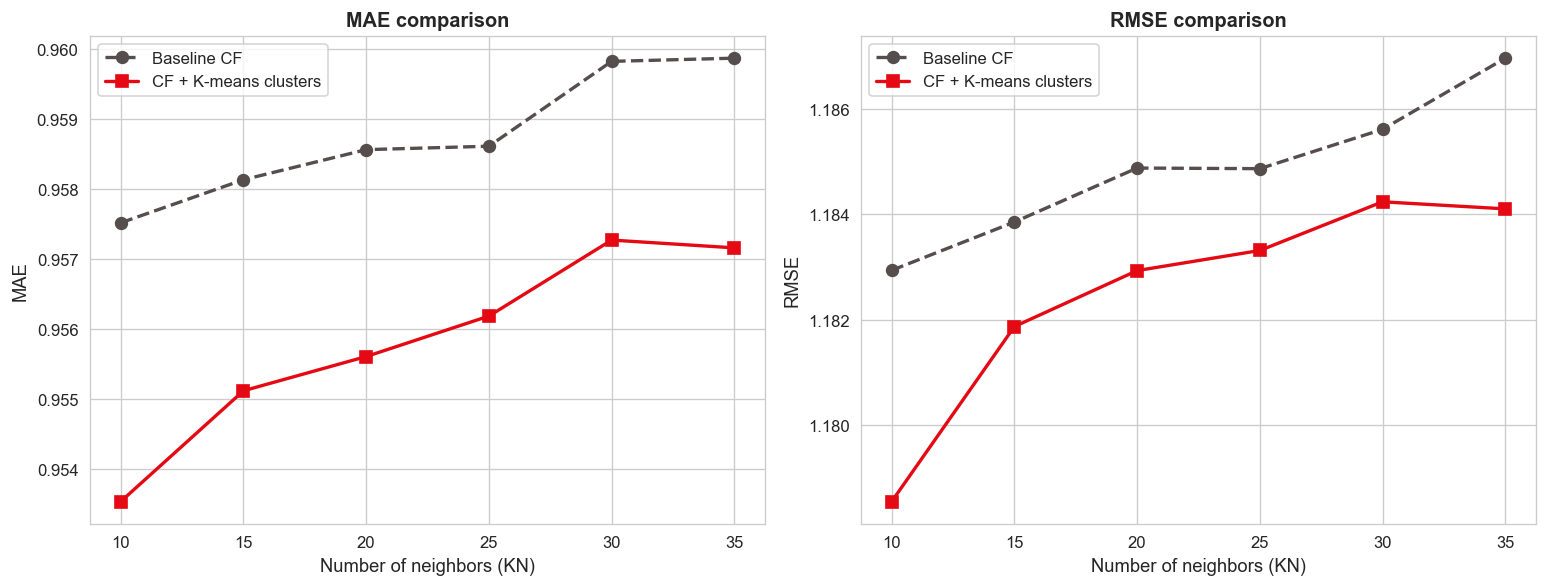

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
k_vals = results_df['KN'].values

for ax, metric, title in zip(axes, ['MAE','RMSE'], ['MAE comparison','RMSE comparison']):
    ax.plot(k_vals, results_df[f'{metric}_base'],    'o--', color='#564d4d',
            linewidth=2, markersize=7, label='Baseline CF')
    ax.plot(k_vals, results_df[f'{metric}_cluster'], 's-',  color='#E50914',
            linewidth=2, markersize=7, label='CF + K-means clusters')
    ax.set_xlabel('Number of neighbors (KN)', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig('wykres_mae_rmse.png', bbox_inches='tight')
plt.show()

## 7. Sample Top-10 recommendations

In [22]:
def recommend_for_user(user_id, train_df, user_profiles, movies,
                        user2idx, n_neighbors=20, top_n=10):
    """Generates Top-N recommendations using CF with clusters."""
    cluster_id    = user_profiles.set_index('user_id')['cluster'].get(user_id, -1)
    cluster_users = user_profiles[user_profiles['cluster'] == cluster_id]['user_id'].values
    cluster_train = train_df[train_df['user_id'].isin(cluster_users)]
    c_users  = cluster_train['user_id'].unique()
    c_movies = cluster_train['movie_id'].unique()
    if user_id not in c_users:
        print('No training ratings in this cluster.')
        return None
    cu2i = {u: i for i, u in enumerate(c_users)}
    cm2i = {m: i for i, m in enumerate(c_movies)}
    ci2m = {i: m for m, i in cm2i.items()}
    cluster_matrix = csr_matrix(
        (cluster_train['rating'].values,
         (cluster_train['user_id'].map(cu2i).values,
          cluster_train['movie_id'].map(cm2i).values)),
        shape=(len(c_users), len(c_movies))
    )
    u_local = cu2i[user_id]
    k       = min(n_neighbors + 1, len(c_users))
    model   = NearestNeighbors(n_neighbors=k, metric='cosine', algorithm='brute')
    model.fit(cluster_matrix)
    distances, indices = model.kneighbors(cluster_matrix[u_local], n_neighbors=k)
    neighbors = [(idx, dist) for idx, dist in zip(indices[0], distances[0]) if idx != u_local]
    seen      = set(train_df[train_df['user_id'] == user_id]['movie_id'].values)
    scores    = {}
    for m_local in range(len(c_movies)):
        m_id = ci2m[m_local]
        if m_id in seen:
            continue
        ratings_n, sims = [], []
        for n_idx, dist in neighbors:
            r = cluster_matrix[n_idx, m_local]
            if r > 0:
                ratings_n.append(r); sims.append(1 - dist)
        if ratings_n and sum(sims) > 0:
            scores[m_id] = np.average(ratings_n, weights=sims)
    top_movies = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    recs = pd.DataFrame(top_movies, columns=['movie_id','predicted_rating'])
    recs = recs.merge(movies[['movie_id','title','genre_primary','imdb_rating',
                               'content_type']], on='movie_id', how='left')
    recs['predicted_rating'] = recs['predicted_rating'].round(2)
    recs.index = range(1, len(recs)+1)
    return recs

example_user = reviews['user_id'].sample(1, random_state=7).values[0]
u_cluster    = user_profiles.set_index('user_id')['cluster'].get(example_user, '?')
print(f'Recommendations for: {example_user}  (Cluster {u_cluster})')
recs = recommend_for_user(example_user, train_df, user_profiles, movies,
                           user2idx, n_neighbors=20, top_n=10)
if recs is not None:
    recs[['title','genre_primary','content_type','imdb_rating','predicted_rating']]

Recommendations for: user_07228  (Cluster 1)


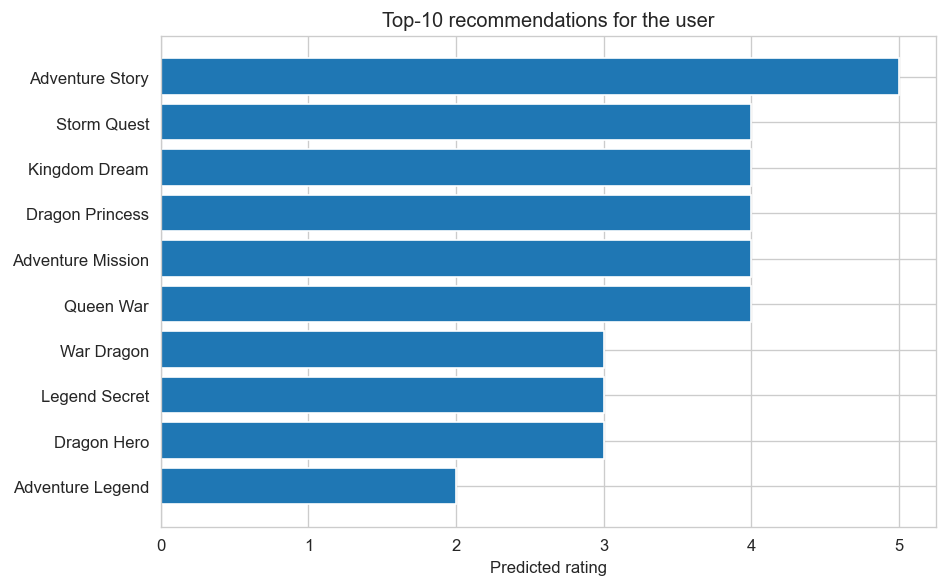

In [23]:
recs_plot = recs.sort_values('predicted_rating')

plt.figure(figsize=(8,5))
plt.barh(recs_plot['title'], recs_plot['predicted_rating'])
plt.xlabel('Predicted rating')
plt.title('Top-10 recommendations for the user')
plt.tight_layout()
plt.show()

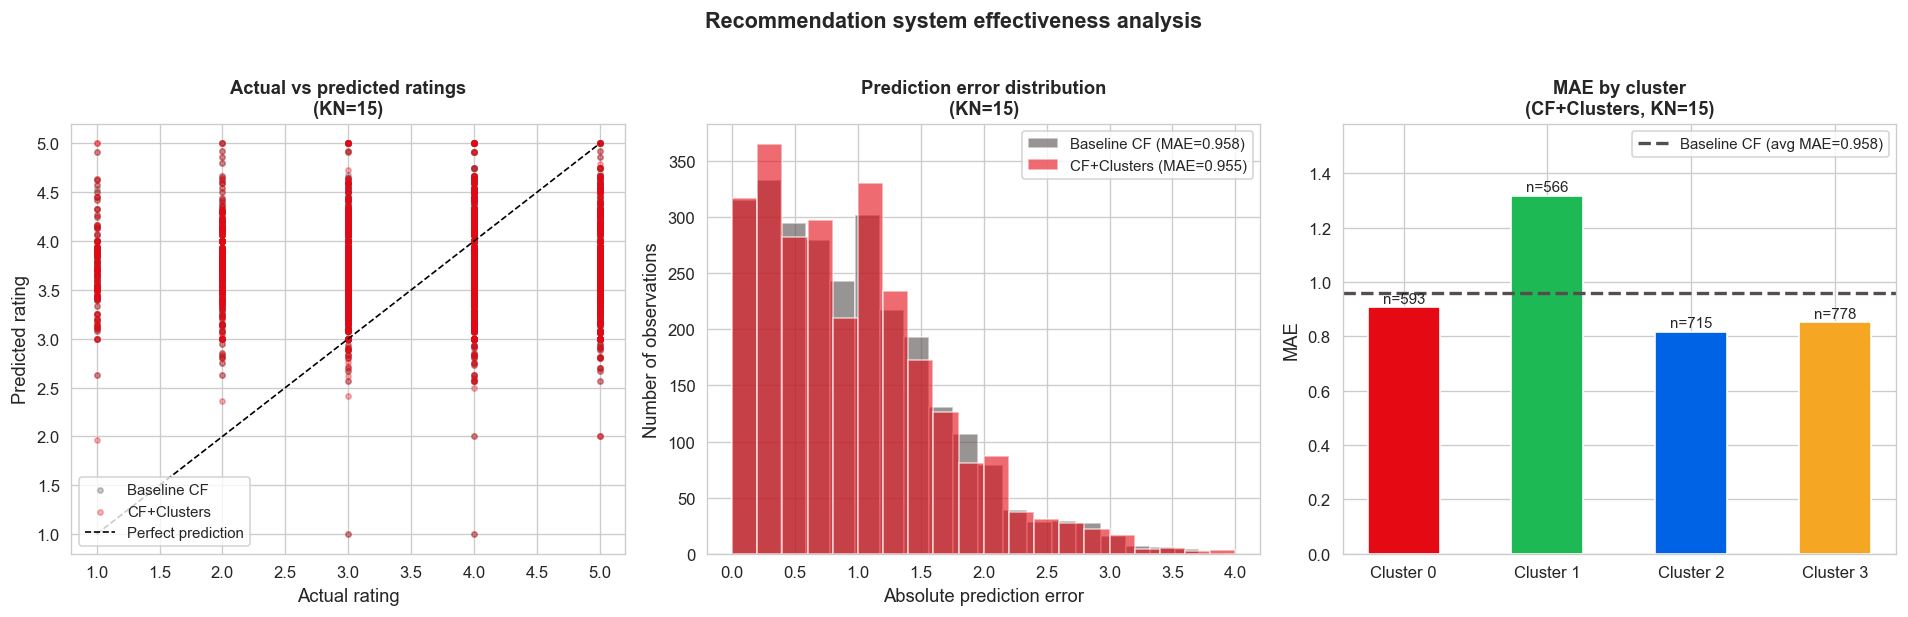

In [24]:
# Visualization: how similar are neighbors within a cluster vs globally
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Distribution of predicted vs actual ratings ---
axes[0].hist(test_sample['rating'], bins=10, alpha=0.6,
             color='#564d4d', label='Actual ratings', edgecolor='white')
axes[0].hist(results_df['MAE_cluster'].values, bins=5, alpha=0.6,
             color='#E50914', label='MAE CF+Clusters', edgecolor='white')
# Better: scatter of actual vs predicted
y_true_best, y_pred_best = predict_ratings_cluster_cf(
    test_sample, train_df, user_profiles, user2idx,
    train_matrix, movie2idx, n_neighbors=15)
y_true_base, y_pred_base = predict_ratings_knn(
    test_sample, train_matrix, n_neighbors=15)

axes[0].clear()
axes[0].scatter(y_true_base, y_pred_base, alpha=0.3, s=10,
                color='#564d4d', label='Baseline CF')
axes[0].scatter(y_true_best, y_pred_best, alpha=0.3, s=10,
                color='#E50914', label='CF+Clusters')
axes[0].plot([1,5],[1,5], 'k--', linewidth=1, label='Perfect prediction')
axes[0].set_xlabel('Actual rating', fontsize=11)
axes[0].set_ylabel('Predicted rating', fontsize=11)
axes[0].set_title('Actual vs predicted ratings\n(KN=15)',
                   fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# --- Plot 2: Prediction error distribution ---
errors_base    = np.abs(y_true_base - y_pred_base)
errors_cluster = np.abs(y_true_best - y_pred_best)

axes[1].hist(errors_base, bins=20, alpha=0.6, color='#564d4d',
             label=f'Baseline CF (MAE={errors_base.mean():.3f})', edgecolor='white')
axes[1].hist(errors_cluster, bins=20, alpha=0.6, color='#E50914',
             label=f'CF+Clusters (MAE={errors_cluster.mean():.3f})', edgecolor='white')
axes[1].set_xlabel('Absolute prediction error', fontsize=11)
axes[1].set_ylabel('Number of observations', fontsize=11)
axes[1].set_title('Prediction error distribution\n(KN=15)',
                   fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

# --- Plot 3: MAE by cluster ---
mae_per_cluster = []
for c in range(K_OPTIMAL):
    test_c = test_sample[test_sample['cluster'] == c]
    if len(test_c) > 0:
        yt, yp = predict_ratings_cluster_cf(
            test_c, train_df, user_profiles, user2idx,
            train_matrix, movie2idx, n_neighbors=15)
        mae_per_cluster.append({
            'Cluster': f'Cluster {c}',
            'MAE': mean_absolute_error(yt, yp),
            'n': len(test_c)
        })

mae_df = pd.DataFrame(mae_per_cluster)
bars = axes[2].bar(mae_df['Cluster'], mae_df['MAE'],
                    color=['#E50914','#1DB954','#0063e5','#f5a623'],
                    edgecolor='white', width=0.5)
axes[2].axhline(y=errors_base.mean(), color='#564d4d', linestyle='--',
                linewidth=2, label=f'Baseline CF (avg MAE={errors_base.mean():.3f})')
for bar, row in zip(bars, mae_df.itertuples()):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'n={row.n}', ha='center', va='bottom', fontsize=9)
axes[2].set_ylabel('MAE', fontsize=11)
axes[2].set_title('MAE by cluster\n(CF+Clusters, KN=15)',
                   fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].set_ylim(0, max(mae_df['MAE'].max(), errors_base.mean()) * 1.2)

plt.suptitle('Recommendation system effectiveness analysis',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wykres_analiza_skutecznosci.png', bbox_inches='tight')
plt.show()

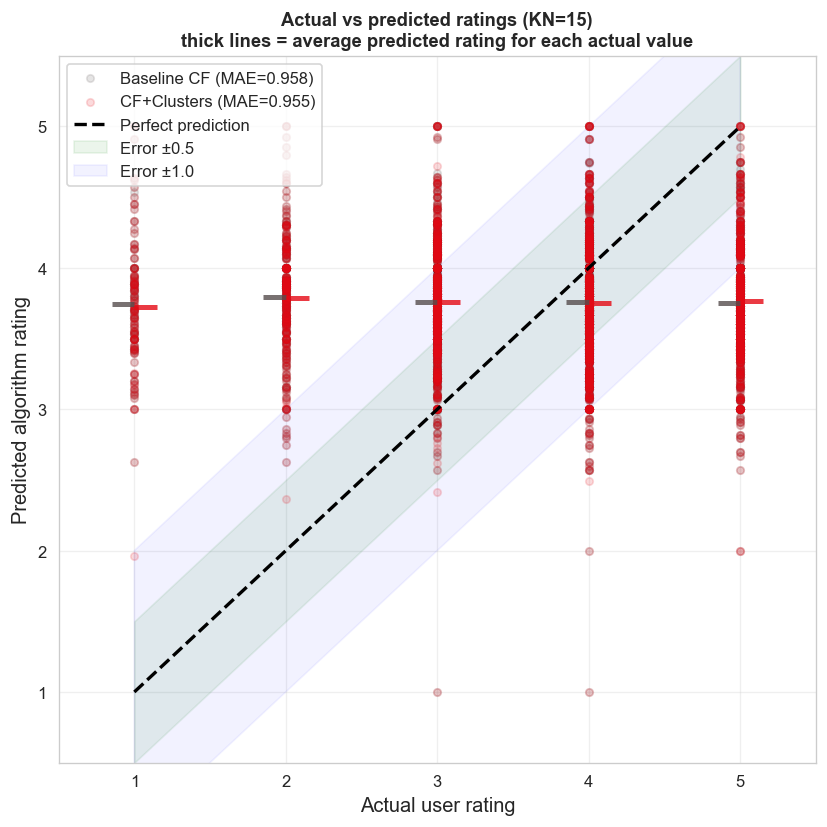

In [25]:
# Scatter plot - clearer version
fig, ax = plt.subplots(figsize=(7, 7))

# Baseline CF - gray points
ax.scatter(y_true_base, y_pred_base,
           alpha=0.15, s=20, color='#564d4d',
           label=f'Baseline CF (MAE={mean_absolute_error(y_true_base, y_pred_base):.3f})',
           zorder=1)

# CF+Clusters - red points
ax.scatter(y_true_best, y_pred_best,
           alpha=0.15, s=20, color='#E50914',
           label=f'CF+Clusters (MAE={mean_absolute_error(y_true_best, y_pred_best):.3f})',
           zorder=2)

# Perfect prediction
ax.plot([1, 5], [1, 5], 'k--', linewidth=2, label='Perfect prediction', zorder=3)

# Error bands ±0.5 and ±1.0
ax.fill_between([1, 5], [0.5, 4.5], [1.5, 5.5],
                alpha=0.08, color='green', label='Error ±0.5')
ax.fill_between([1, 5], [0, 4], [2, 6],
                alpha=0.05, color='blue', label='Error ±1.0')

# Average predicted rating for each actual value
for val in [1, 2, 3, 4, 5]:
    mask_base    = y_true_base == val
    mask_cluster = y_true_best == val
    if mask_base.sum() > 0:
        ax.hlines(y_pred_base[mask_base].mean(), val-0.15, val,
                  colors='#564d4d', linewidth=3, alpha=0.8)
    if mask_cluster.sum() > 0:
        ax.hlines(y_pred_best[mask_cluster].mean(), val, val+0.15,
                  colors='#E50914', linewidth=3, alpha=0.8)

ax.set_xlabel('Actual user rating', fontsize=12)
ax.set_ylabel('Predicted algorithm rating', fontsize=12)
ax.set_title('Actual vs predicted ratings (KN=15)\nthick lines = average predicted rating for each actual value',
             fontsize=11, fontweight='bold')
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_yticks([1, 2, 3, 4, 5])
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('wykres_scatter_czytelny.png', bbox_inches='tight')
plt.show()

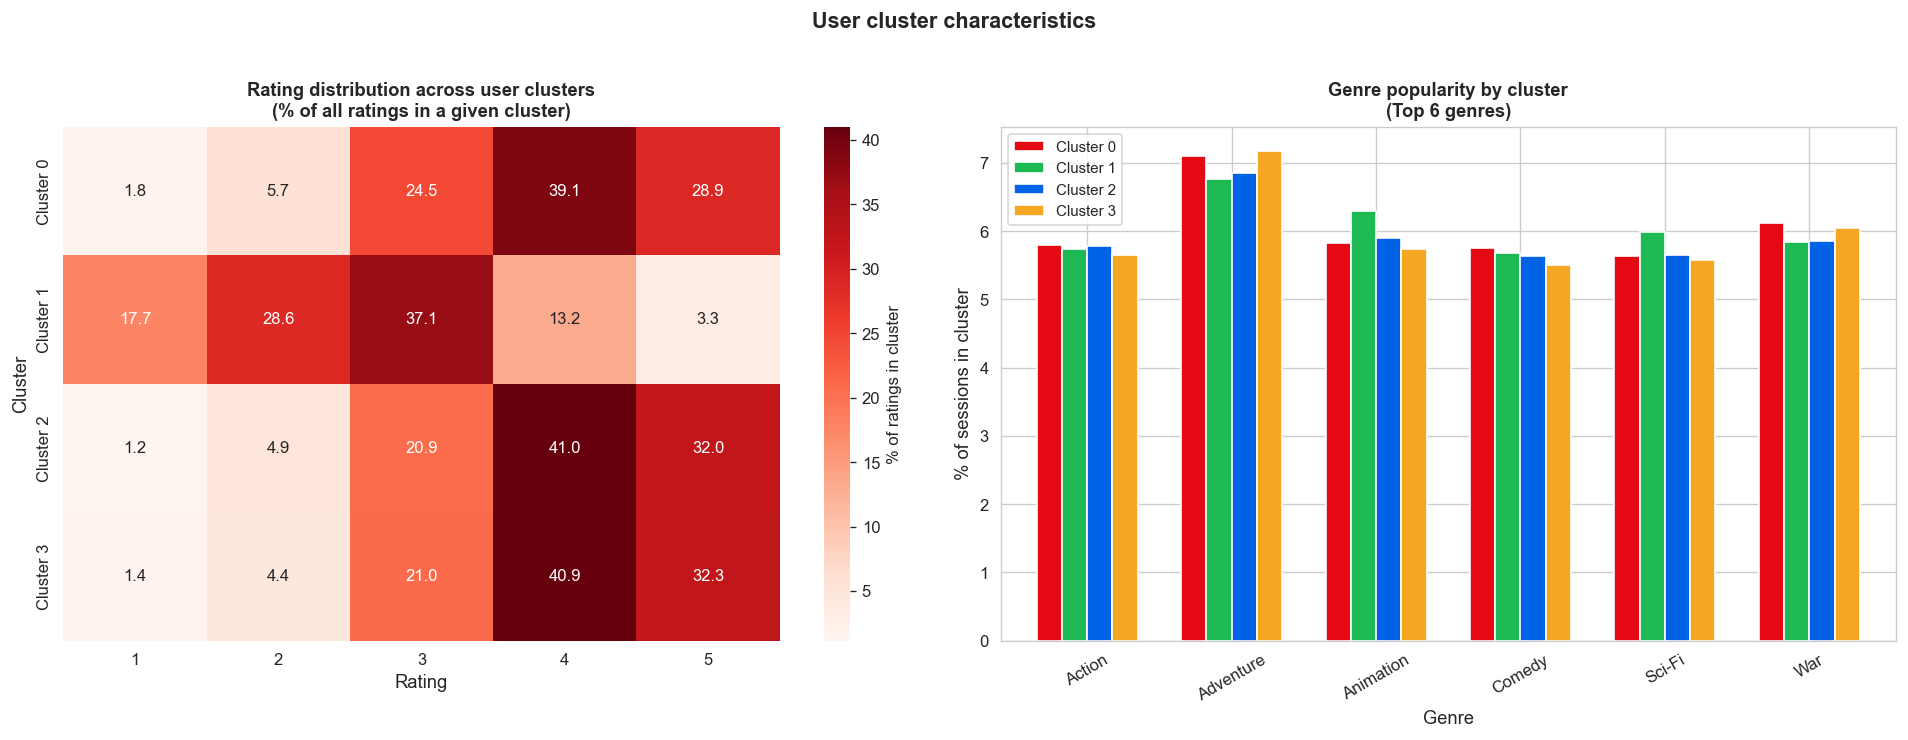

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Rating heatmap by cluster ---
reviews_with_cluster = reviews.merge(
    user_profiles[['user_id','cluster']], on='user_id', how='left')
reviews_with_cluster = reviews_with_cluster.dropna(subset=['cluster'])
reviews_with_cluster['cluster'] = reviews_with_cluster['cluster'].astype(int)

heat_data = reviews_with_cluster.groupby(['cluster','rating']).size().unstack(fill_value=0)
heat_pct  = heat_data.div(heat_data.sum(axis=1), axis=0) * 100

sns.heatmap(heat_pct, annot=True, fmt='.1f', cmap='Reds',
            ax=axes[0], cbar_kws={'label': '% of ratings in cluster'},
            xticklabels=[1,2,3,4,5],
            yticklabels=[f'Cluster {i}' for i in range(K_OPTIMAL)])
axes[0].set_xlabel('Rating', fontsize=11)
axes[0].set_ylabel('Cluster', fontsize=11)
axes[0].set_title('Rating distribution across user clusters\n(% of all ratings in a given cluster)',
                   fontsize=11, fontweight='bold')

# --- Plot 2: Top genres per cluster ---
watch_with_cluster = watch_history.merge(
    user_profiles[['user_id','cluster']], on='user_id', how='left')
watch_with_cluster = watch_with_cluster.merge(
    movies[['movie_id','genre_primary']], on='movie_id', how='left')
watch_with_cluster = watch_with_cluster.dropna(subset=['cluster','genre_primary'])
watch_with_cluster['cluster'] = watch_with_cluster['cluster'].astype(int)

genre_cluster = watch_with_cluster.groupby(['cluster','genre_primary']).size().reset_index(name='count')
genre_cluster['pct'] = genre_cluster.groupby('cluster')['count'].transform(lambda x: x/x.sum()*100)

top_genres = genre_cluster.groupby('genre_primary')['count'].sum().nlargest(6).index
genre_top  = genre_cluster[genre_cluster['genre_primary'].isin(top_genres)]
genre_pivot = genre_top.pivot(index='genre_primary', columns='cluster', values='pct').fillna(0)

genre_pivot.plot(kind='bar', ax=axes[1], color=colors, width=0.7, edgecolor='white')
axes[1].set_xlabel('Genre', fontsize=11)
axes[1].set_ylabel('% of sessions in cluster', fontsize=11)
axes[1].set_title('Genre popularity by cluster\n(Top 6 genres)',
                   fontsize=11, fontweight='bold')
axes[1].legend([f'Cluster {i}' for i in range(K_OPTIMAL)], fontsize=9)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('User cluster characteristics', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wykres_klastry_charakterystyka.png', bbox_inches='tight')
plt.show()

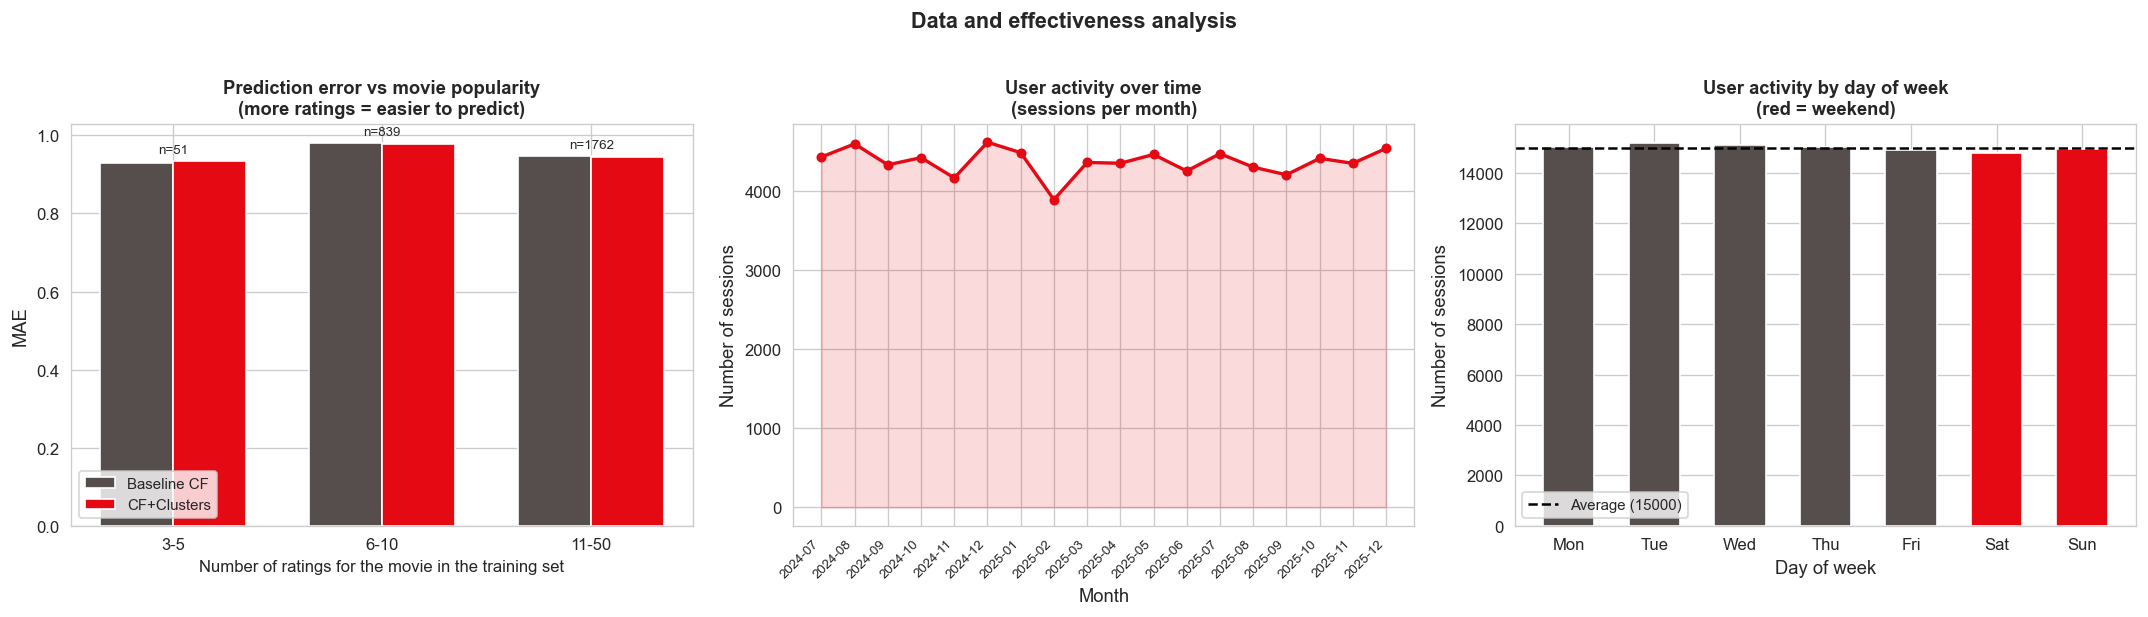

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 3: Error vs movie popularity ---
movie_rating_counts = train_df.groupby('movie_id').size().reset_index(name='n_ratings')

errors_df = pd.DataFrame({
    'movie_id': test_sample['movie_id'].values,
    'error_cluster': np.abs(y_true_best - y_pred_best),
    'error_base':    np.abs(y_true_base - y_pred_base)
})
errors_df = errors_df.merge(movie_rating_counts, on='movie_id', how='left')
errors_df['popularity'] = pd.cut(errors_df['n_ratings'],
                                   bins=[0,2,5,10,50,1000],
                                   labels=['1-2','3-5','6-10','11-50','50+'])
errors_df = errors_df.dropna(subset=['popularity'])

pop_summary = errors_df.groupby('popularity', observed=True).agg(
    MAE_base    = ('error_base', 'mean'),
    MAE_cluster = ('error_cluster', 'mean'),
    n           = ('error_base', 'count')
).reset_index()

x = np.arange(len(pop_summary))
w = 0.35
axes[0].bar(x - w/2, pop_summary['MAE_base'],    w, color='#564d4d',
            label='Baseline CF', edgecolor='white')
axes[0].bar(x + w/2, pop_summary['MAE_cluster'], w, color='#E50914',
            label='CF+Clusters', edgecolor='white')
for i, row in enumerate(pop_summary.itertuples()):
    axes[0].text(i, max(row.MAE_base, row.MAE_cluster) + 0.02,
                 f'n={row.n}', ha='center', fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(pop_summary['popularity'])
axes[0].set_xlabel('Number of ratings for the movie in the training set', fontsize=10)
axes[0].set_ylabel('MAE', fontsize=11)
axes[0].set_title('Prediction error vs movie popularity\n(more ratings = easier to predict)',
                   fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# --- Plot 4: Activity over time ---
watch_history['month'] = pd.to_datetime(watch_history['watch_date']).dt.to_period('M')
monthly = watch_history.groupby('month').size().reset_index(name='sessions')
monthly['month_str'] = monthly['month'].astype(str)
monthly = monthly.tail(18)

axes[1].plot(monthly['month_str'], monthly['sessions'],
             'o-', color='#E50914', linewidth=2, markersize=5)
axes[1].fill_between(range(len(monthly)), monthly['sessions'],
                      alpha=0.15, color='#E50914')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['month_str'], rotation=45, ha='right', fontsize=8)
axes[1].set_xlabel('Month', fontsize=11)
axes[1].set_ylabel('Number of sessions', fontsize=11)
axes[1].set_title('User activity over time\n(sessions per month)',
                   fontsize=11, fontweight='bold')

# --- Plot 5: Activity by day of week ---
watch_history['dayofweek'] = pd.to_datetime(watch_history['watch_date']).dt.dayofweek
day_names = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_counts = watch_history.groupby('dayofweek').size()

bar_colors = ['#564d4d']*5 + ['#E50914']*2
axes[2].bar(day_names, day_counts.values, color=bar_colors, edgecolor='white', width=0.6)
axes[2].set_xlabel('Day of week', fontsize=11)
axes[2].set_ylabel('Number of sessions', fontsize=11)
axes[2].set_title('User activity by day of week\n(red = weekend)',
                   fontsize=11, fontweight='bold')

mean_val = day_counts.mean()
axes[2].axhline(y=mean_val, color='black', linestyle='--',
                linewidth=1.5, label=f'Average ({mean_val:.0f})')
axes[2].legend(fontsize=9)

plt.suptitle('Data and effectiveness analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wykres_analiza_danych.png', bbox_inches='tight')
plt.show()

Computing the learning curve...


  10% of training data (1,236 ratings): MAE Baseline=1.092  MAE Clusters=1.054


  20% of training data (2,472 ratings): MAE Baseline=1.052  MAE Clusters=1.036


  30% of training data (3,708 ratings): MAE Baseline=1.028  MAE Clusters=1.021


  40% of training data (4,944 ratings): MAE Baseline=0.996  MAE Clusters=0.995


  50% of training data (6,180 ratings): MAE Baseline=0.982  MAE Clusters=0.980


  60% of training data (7,416 ratings): MAE Baseline=0.971  MAE Clusters=0.969


  70% of training data (8,652 ratings): MAE Baseline=0.966  MAE Clusters=0.963


  80% of training data (9,888 ratings): MAE Baseline=0.965  MAE Clusters=0.961


  90% of training data (11,124 ratings): MAE Baseline=0.964  MAE Clusters=0.959


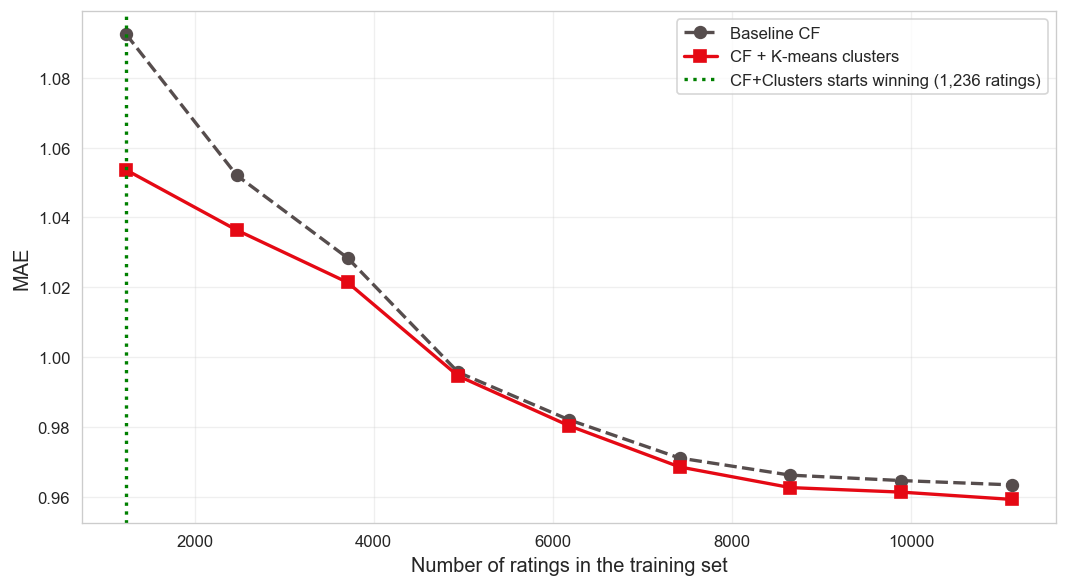

In [28]:
# Learning curve — how MAE changes with training set size
from sklearn.model_selection import train_test_split

train_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
mae_base_curve    = []
mae_cluster_curve = []
n_train_sizes     = []

print('Computing the learning curve...')
for size in train_sizes:
    # Split training data into a smaller subset
    train_sub, _ = train_test_split(train_df, train_size=size, random_state=42)

    # Build the matrix for the subset
    train_sub_matrix = csr_matrix(
        (train_sub['rating'].values,
         (train_sub['u_idx'].values, train_sub['m_idx'].values)),
        shape=(n_users, n_movies)
    )

    # Evaluate on a fixed test set (500 samples)
    yt_b, yp_b = predict_ratings_knn(
        test_sample, train_sub_matrix, n_neighbors=15)
    yt_c, yp_c = predict_ratings_cluster_cf(
        test_sample, train_sub, user_profiles, user2idx,
        train_sub_matrix, movie2idx, n_neighbors=15)

    mae_base_curve.append(mean_absolute_error(yt_b, yp_b))
    mae_cluster_curve.append(mean_absolute_error(yt_c, yp_c))
    n_train_sizes.append(len(train_sub))
    print(f'  {size*100:.0f}% of training data ({len(train_sub):,} ratings): '
          f'MAE Baseline={mae_base_curve[-1]:.3f}  MAE Clusters={mae_cluster_curve[-1]:.3f}')

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(n_train_sizes, mae_base_curve, 'o--', color='#564d4d',
        linewidth=2, markersize=7, label='Baseline CF')
ax.plot(n_train_sizes, mae_cluster_curve, 's-', color='#E50914',
        linewidth=2, markersize=7, label='CF + K-means clusters')

# Mark the point where CF+Clusters starts winning
crossover = next((i for i in range(len(mae_base_curve))
                  if mae_cluster_curve[i] < mae_base_curve[i]), None)
if crossover is not None:
    ax.axvline(x=n_train_sizes[crossover], color='green',
               linestyle=':', linewidth=2,
               label=f'CF+Clusters starts winning ({n_train_sizes[crossover]:,} ratings)')

ax.set_xlabel('Number of ratings in the training set', fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Annotation — full training set
ax.annotate(f'Full set\n({len(train_df):,} ratings)',
            xy=(len(train_df), mae_cluster_curve[-1]),
            xytext=(len(train_df)*0.7, mae_cluster_curve[-1]+0.02),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9)

plt.tight_layout()
plt.savefig('wykres_krzywa_uczenia.png', bbox_inches='tight')
plt.show()

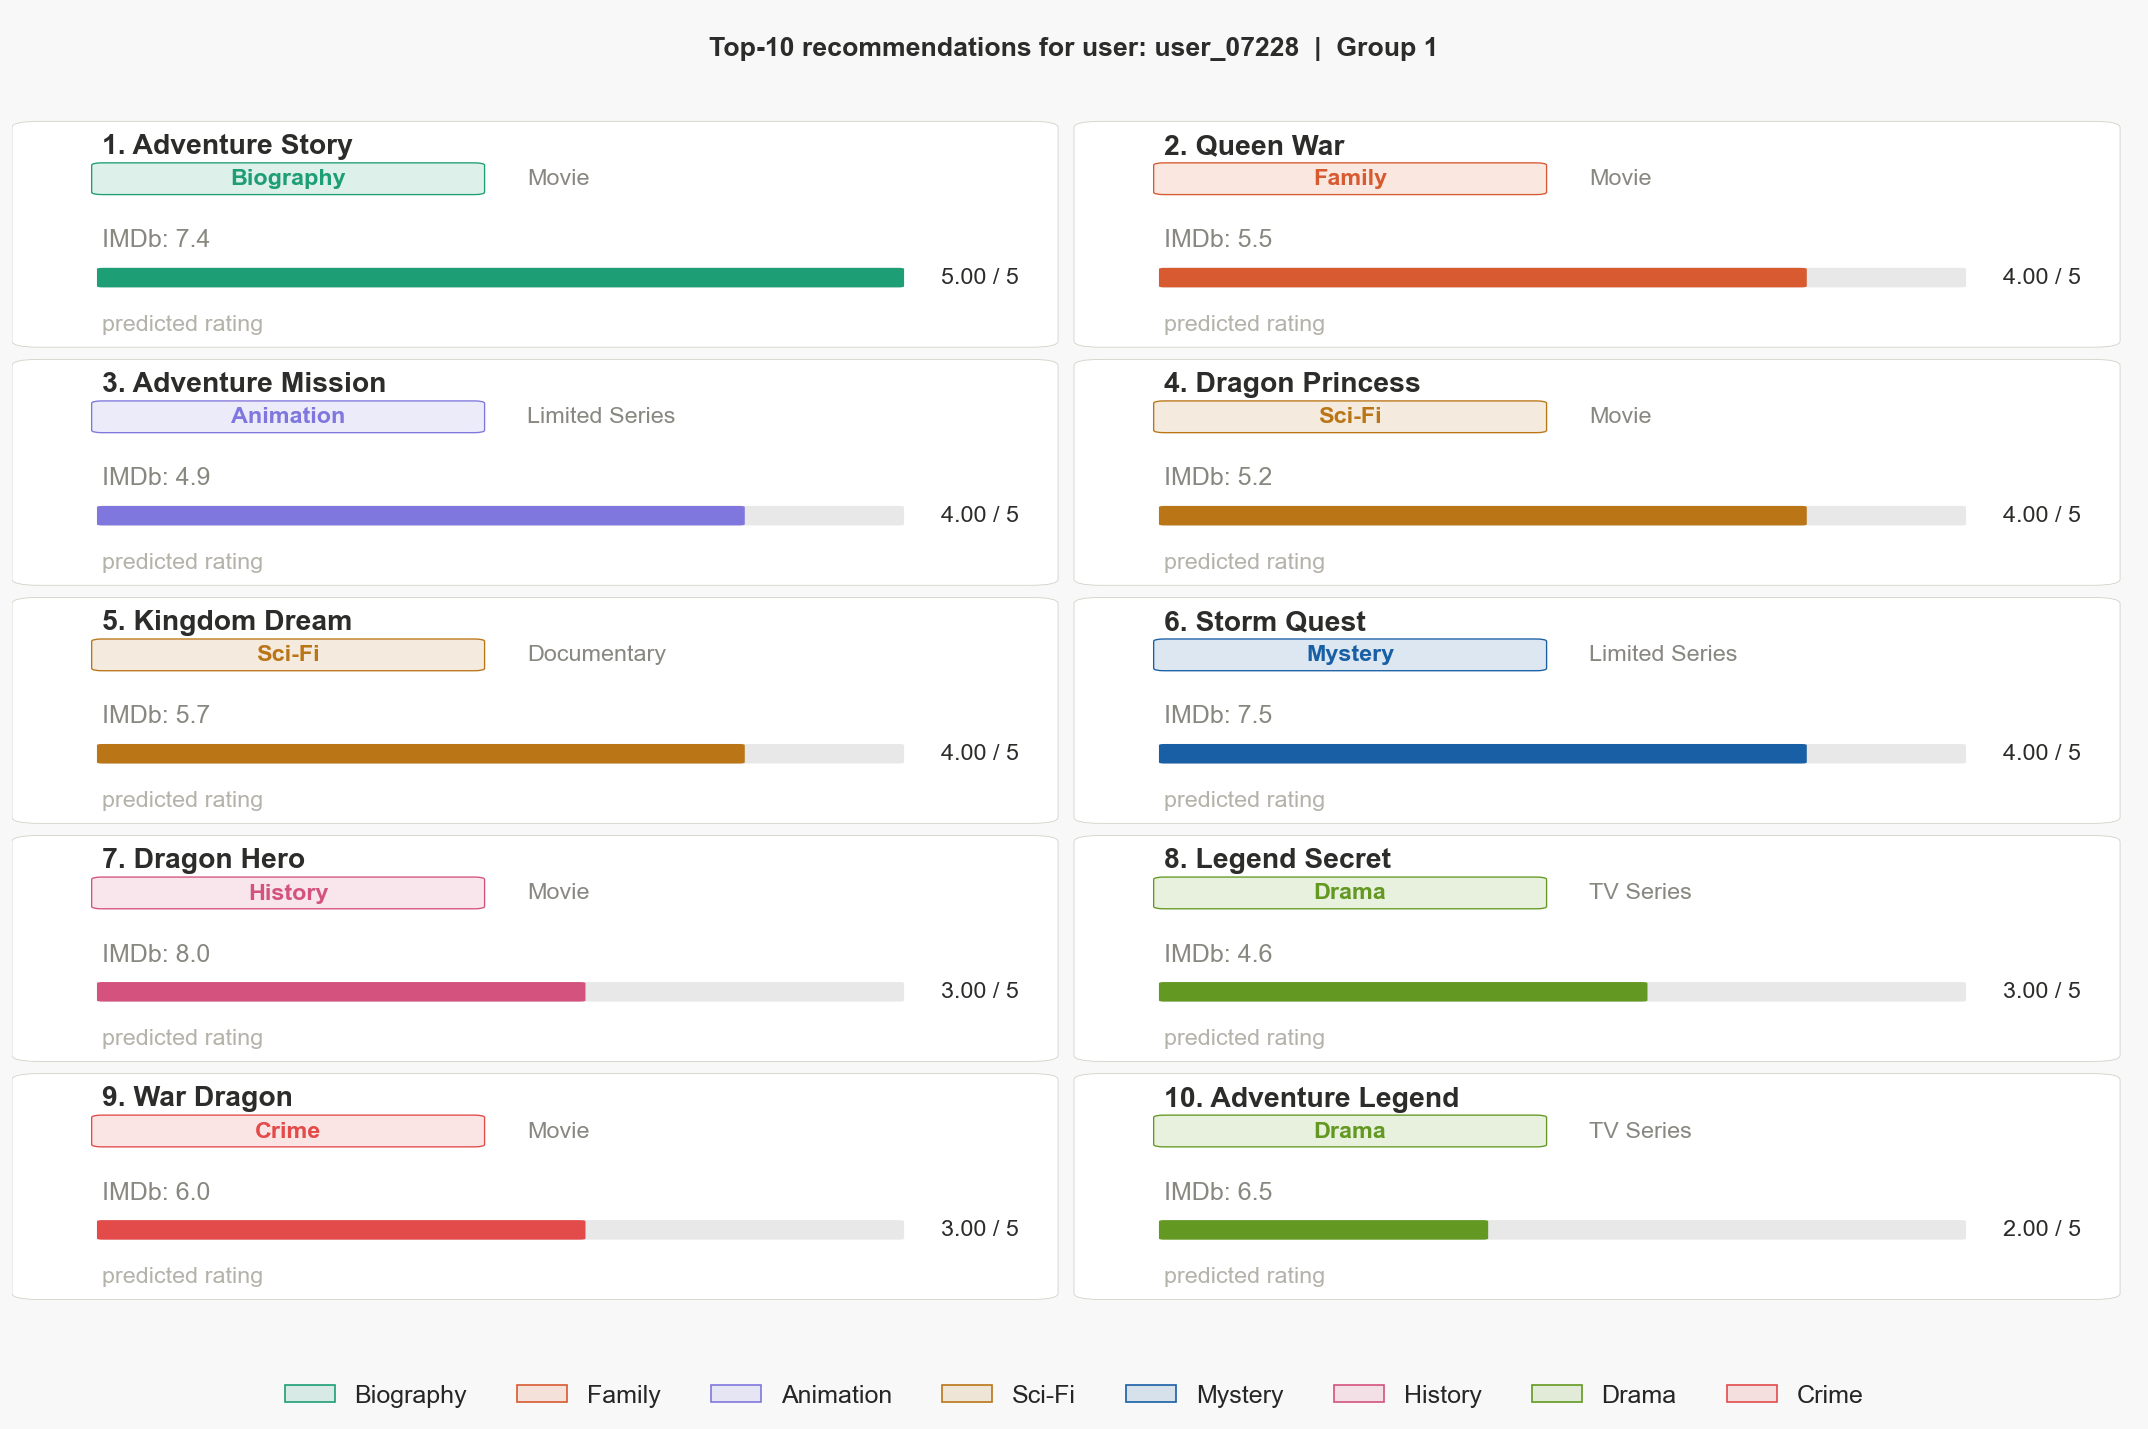

In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

genre_display = {
    "Biography": "Biography",
    "Family": "Family",
    "Animation": "Animation",
    "Sci-Fi": "Sci-Fi",
    "Mystery": "Mystery",
    "History": "History",
    "Drama": "Drama",
    "Crime": "Crime",
    "Action": "Action",
    "Comedy": "Comedy",
    "Horror": "Horror",
    "Romance": "Romance",
    "Thriller": "Thriller",
    "Documentary": "Documentary",
    "Adventure": "Adventure",
    "Fantasy": "Fantasy",
}

type_display = {
    "Movie": "Movie",
    "TV Series": "TV Series",
    "Limited Series": "Limited Series",
    "Documentary": "Documentary",
}

if recs is not None:
    films = []
    for _, row in recs.iterrows():
        films.append({
            "title": row["title"],
            "genre": genre_display.get(row["genre_primary"], row["genre_primary"]),
            "score": row["predicted_rating"],
            "type":  type_display.get(row["content_type"], row["content_type"]),
            "imdb":  row["imdb_rating"]
        })

    genres  = [genre_display.get(g, g) for g in recs["genre_primary"].unique()]
    palette = ["#1D9E75","#D85A30","#7F77DD","#BA7517","#185FA5","#D4537E","#639922","#E24B4A"]
    genre_colors = {g: palette[i % len(palette)] for i, g in enumerate(genres)}

    fig, ax = plt.subplots(figsize=(18, 12))
    ax.set_xlim(0, 4)
    ax.set_ylim(-0.5, 11)
    ax.axis("off")
    fig.patch.set_facecolor("#F8F8F8")

    ax.text(2, 10.7,
            f"Top-10 recommendations for user: {example_user}  |  Group {u_cluster}",
            ha="center", va="center", fontsize=16, fontweight="bold", color="#2C2C2A")

    cols = 2
    for i, film in enumerate(films):
        row_i = i // cols
        col_i = i % cols
        x = col_i * 2 + 0.05
        y = 10.0 - row_i * 1.95

        box = FancyBboxPatch((x, y - 1.7), 1.87, 1.75,
                              boxstyle="round,pad=0.05",
                              linewidth=0.5,
                              edgecolor="#D3D1C7",
                              facecolor="white")
        ax.add_patch(box)

        color = genre_colors.get(film["genre"], "#888780")

        # Number and title
        ax.text(x + 0.12, y + 0.0,
                f"{i+1}. {film['title']}",
                fontsize=17, fontweight="bold", color="#2C2C2A", va="top")

        # Genre badge
        badge = FancyBboxPatch((x + 0.12, y - 0.48), 0.7, 0.22,
                                boxstyle="round,pad=0.02",
                                linewidth=0.8,
                                facecolor=color + "25",
                                edgecolor=color)
        ax.add_patch(badge)
        ax.text(x + 0.47, y - 0.37, film["genre"],
                fontsize=14, color=color, va="center", ha="center", fontweight="bold")

        # Type
        ax.text(x + 0.92, y - 0.37, film["type"],
                fontsize=14, color="#888780", va="center")

        # IMDb
        ax.text(x + 0.12, y - 0.78,
                f"IMDb: {film['imdb']:.1f}",
                fontsize=15, color="#888780", va="top")

        # Rating bar
        max_bar = 1.5
        bar_w   = film["score"] / 5 * max_bar
        ax.add_patch(FancyBboxPatch((x + 0.12, y - 1.25), max_bar, 0.14,
                                     boxstyle="round,pad=0.01",
                                     facecolor="#E8E8E8",
                                     edgecolor="none"))
        ax.add_patch(FancyBboxPatch((x + 0.12, y - 1.25), bar_w, 0.14,
                                     boxstyle="round,pad=0.01",
                                     facecolor=color,
                                     edgecolor="none"))
        ax.text(x + 0.12 + max_bar + 0.08, y - 1.18,
                f"{film['score']:.2f} / 5",
                fontsize=14, color="#2C2C2A", va="center")

        ax.text(x + 0.12, y - 1.48,
                "predicted rating",
                fontsize=14, color="#B4B2A9", va="top")

    legend_elements = [mpatches.Patch(facecolor=c + "25", edgecolor=c, label=g)
                       for g, c in genre_colors.items()]
    ax.legend(handles=legend_elements, loc="lower center",
              bbox_to_anchor=(0.5, -0.01), ncol=len(genre_colors),
              frameon=False, fontsize=15)

    plt.tight_layout()
    plt.savefig("rekomendacje_panel.png", bbox_inches="tight", dpi=200)
    plt.show()

## 8. Results summary

In [30]:
mae_b_avg  = results_df['MAE_base'].mean()
mae_c_avg  = results_df['MAE_cluster'].mean()
rmse_b_avg = results_df['RMSE_base'].mean()
rmse_c_avg = results_df['RMSE_cluster'].mean()
imp_mae    = (mae_b_avg - mae_c_avg) / mae_b_avg * 100
imp_rmse   = (rmse_b_avg - rmse_c_avg) / rmse_b_avg * 100

print('=' * 55)
print('RESULTS SUMMARY')
print('=' * 55)
print(f'  Method                | Avg. MAE | Avg. RMSE')
print(f'  Baseline CF (user-KNN)| {mae_b_avg:.3f}    | {rmse_b_avg:.3f}')
print(f'  CF + K-means clusters | {mae_c_avg:.3f}    | {rmse_c_avg:.3f}')
print(f'  MAE improvement:   {imp_mae:+.1f}%')
print(f'  RMSE improvement:  {imp_rmse:+.1f}%')
print('=' * 55)
best_k = results_df.loc[results_df['MAE_cluster'].idxmin(), 'KN']
print(f'  Best k (CF+Clusters): {best_k}')

RESULTS SUMMARY
  Method                | Avg. MAE | Avg. RMSE
  Baseline CF (user-KNN)| 0.959    | 1.185
  CF + K-means clusters | 0.956    | 1.183
  MAE improvement:   +0.3%
  RMSE improvement:  +0.2%
  Best k (CF+Clusters): 10
